# 14_2. 행정동 유형화 최종 확정 — 4사분면 + 6개 세부유형

14번에서 다양한 변수 조합·알고리즘·군집 수를 비교한 결과를 바탕으로,
이번 노트북에서는 최종 서비스 활용용 유형화를 확정한다.

## 최종 구조

### 상위 설명 레이어
**4사분면**
- 저주거비·저통근부담
- 저주거비·고통근부담
- 고주거비·저통근부담
- 고주거비·고통근부담

### 세부 탐색 레이어
**6개 행정동 유형**
1. 고비용 통근부담형
2. 근접통근 균형형
3. 광역분산 통근형
4. 주거절감·장거리통근형
5. 저주거비·지역연계형
6. 고주거비·직주근접형

최종 군집은 `k=6`으로 고정한다.

청년 1인세대 비율은 군집 생성에는 사용하지 않고,
최종 6개 유형이 어떤 인구구성을 보이는지 확인하는 **사후 해석 변수**로만 사용한다.


In [1]:
# =========================================================
# 1. 라이브러리
# =========================================================

from pathlib import Path
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import platform

from IPython.display import display

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import (
    KMeans,
    MiniBatchKMeans,
    BisectingKMeans,
    AgglomerativeClustering,
    SpectralClustering,
    Birch,
    DBSCAN,
    OPTICS,
    MeanShift,
    estimate_bandwidth,
    AffinityPropagation,
)
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
)
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

try:
    from sklearn.cluster import HDBSCAN
    HDBSCAN_AVAILABLE = True
except Exception:
    HDBSCAN_AVAILABLE = False

try:
    from sklearn_extra.cluster import KMedoids
    KMEDOIDS_AVAILABLE = True
except Exception as error:
    KMEDOIDS_AVAILABLE = False
    KMEDOIDS_IMPORT_ERROR = repr(error)

try:
    import skfuzzy as fuzz
    FUZZY_AVAILABLE = True
except Exception as error:
    FUZZY_AVAILABLE = False
    FUZZY_IMPORT_ERROR = repr(error)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 150)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42
EXPECTED_DONG_COUNT = 427
K_VALUES = range(4, 9)
BOOTSTRAP_REPEATS = 30
BOOTSTRAP_FRACTION = 0.85

print("HDBSCAN 사용 가능:", HDBSCAN_AVAILABLE)
print("K-Medoids 사용 가능:", KMEDOIDS_AVAILABLE)
if not KMEDOIDS_AVAILABLE:
    print("K-Medoids는 현재 환경에서 제외하고 진행합니다.")
print("Fuzzy C-Means 사용 가능:", FUZZY_AVAILABLE)
if not FUZZY_AVAILABLE:
    print("Fuzzy C-Means 오류:", FUZZY_IMPORT_ERROR)


# macOS / Windows 한글 폰트 설정
if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
print("Matplotlib 폰트:", plt.rcParams["font.family"])

from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import cdist


HDBSCAN 사용 가능: True
K-Medoids 사용 가능: False
K-Medoids는 현재 환경에서 제외하고 진행합니다.
Fuzzy C-Means 사용 가능: True
Matplotlib 폰트: ['AppleGothic']


In [2]:

# =========================================================
# 2. 프로젝트 경로
# =========================================================

CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    REPO_DIR = CURRENT_DIR.parent
elif (CURRENT_DIR / "notebooks").exists():
    REPO_DIR = CURRENT_DIR
else:
    raise FileNotFoundError(
        "프로젝트 저장소 위치를 찾지 못했습니다.\n"
        f"현재 위치: {CURRENT_DIR}\n"
        "저장소 루트 또는 notebooks 폴더에서 실행하세요."
    )

WORKSPACE_DIR = REPO_DIR.parent
DATA_DIR = WORKSPACE_DIR / "project_data"
PROCESSED_DIR = DATA_DIR / "processed"

MASTER_FILE = PROCESSED_DIR / "행정동_기준코드표.csv"

# 새 표면주거비 파일
HOUSING_FILE = PROCESSED_DIR / "표면주거비_행정동별.csv"

COMMUTE_FILE = PROCESSED_DIR / "commute_burden_by_home_dong.csv"
NETWORK_FILE = PROCESSED_DIR / "commute_dong_network_metrics.csv"
DESTINATION_FILE = (
    PROCESSED_DIR
    / "commute_destination_concentration_by_home_dong.csv"
)

def find_file_by_name(filename, roots):
    candidates = []
    for root in roots:
        root = Path(root)
        if not root.exists():
            continue
        direct = root / filename
        if direct.exists():
            candidates.append(direct)
        candidates.extend(
            path for path in root.rglob(filename)
            if ".git" not in path.parts
        )

    unique = []
    seen = set()
    for path in candidates:
        resolved = path.resolve()
        if resolved not in seen:
            seen.add(resolved)
            unique.append(path)

    if not unique:
        return None

    unique.sort(
        key=lambda path: (
            "최종_분석용" not in path.parts,
            "processed" not in path.parts,
            len(path.parts),
        )
    )
    return unique[0]

# 2025년 현재 행정동 체계 427개를 우선 사용
YOUTH_FILE = find_file_by_name(
    "youth_single_household_share_2025.csv",
    [PROCESSED_DIR, DATA_DIR, WORKSPACE_DIR],
)

# 아직 02번 파일명을 수정하지 않았을 경우를 위한 후보
if YOUTH_FILE is None:
    YOUTH_FILE = find_file_by_name(
        "youth_single_household_share_2023_2025.csv",
        [PROCESSED_DIR, DATA_DIR, WORKSPACE_DIR],
    )

if YOUTH_FILE is None:
    raise FileNotFoundError(
        "청년 1인세대 파일을 찾지 못했습니다.\n"
        "권장 파일: youth_single_household_share_2025.csv"
    )

OUTPUT_INPUT_FILE = PROCESSED_DIR / "행정동_유형화_입력데이터_v3.csv"
OUTPUT_FIXED_SCORE_FILE = PROCESSED_DIR / "행정동_유형화_고정k_모형비교.csv"
OUTPUT_AUTO_SCORE_FILE = PROCESSED_DIR / "행정동_유형화_자동군집_모형비교.csv"
OUTPUT_FUZZY_FILE = PROCESSED_DIR / "행정동_유형화_퍼지군집_비교.csv"
OUTPUT_PROFILE_FILE = PROCESSED_DIR / "행정동_유형화_군집프로파일_v3.csv"
OUTPUT_RESULT_FILE = PROCESSED_DIR / "행정동_유형화_결과_v3.csv"

for label, path in {
    "기준코드표": MASTER_FILE,
    "표면주거비": HOUSING_FILE,
    "통근부담": COMMUTE_FILE,
    "통근권 지표": NETWORK_FILE,
    "목적지 지표": DESTINATION_FILE,
    "청년 1인세대": YOUTH_FILE,
}.items():
    print(f"{label}: {path}")


기준코드표: /Users/janghwayeong/Desktop/부트캠프_프로젝트/project_data/processed/행정동_기준코드표.csv
표면주거비: /Users/janghwayeong/Desktop/부트캠프_프로젝트/project_data/processed/표면주거비_행정동별.csv
통근부담: /Users/janghwayeong/Desktop/부트캠프_프로젝트/project_data/processed/commute_burden_by_home_dong.csv
통근권 지표: /Users/janghwayeong/Desktop/부트캠프_프로젝트/project_data/processed/commute_dong_network_metrics.csv
목적지 지표: /Users/janghwayeong/Desktop/부트캠프_프로젝트/project_data/processed/commute_destination_concentration_by_home_dong.csv
청년 1인세대: /Users/janghwayeong/Desktop/부트캠프_프로젝트/Analysis-of-Youth-Savings-Capacity-Project/data/youth_single_household_share_2023_2025.csv


In [3]:

# =========================================================
# 3. 공통 함수
# =========================================================

def read_csv_clean(path):
    if path is None or not Path(path).exists():
        raise FileNotFoundError(f"파일을 찾지 못했습니다: {path}")

    df = pd.read_csv(path, encoding="utf-8-sig", low_memory=False)
    df.columns = (
        df.columns.astype(str)
        .str.replace("\ufeff", "", regex=False)
        .str.strip()
    )
    return df


def normalize_admin_code_value(value):
    if pd.isna(value):
        return pd.NA

    text = str(value).strip()
    text = re.sub(r"\.0$", "", text)
    digits = re.sub(r"\D", "", text)

    if len(digits) == 8:
        return digits + "00"

    if len(digits) == 10:
        if digits.startswith("00"):
            return digits[2:] + "00"
        return digits

    return pd.NA


def normalize_code(series):
    return series.map(normalize_admin_code_value).astype("string")


def find_column(df, candidates, label, required=True):
    column = next((c for c in candidates if c in df.columns), None)
    if column is None and required:
        raise KeyError(
            f"{label}에서 필요한 열을 찾지 못했습니다.\n"
            f"후보: {candidates}\n"
            f"현재 열: {df.columns.tolist()}"
        )
    return column


def numeric_clean(df, columns):
    result = df.copy()
    for column in columns:
        if column in result.columns:
            result[column] = pd.to_numeric(
                result[column], errors="coerce"
            )
    return result


def assert_unique_code(df, code_column, label):
    duplicated = df[code_column].duplicated(keep=False)
    if duplicated.any():
        display(df.loc[duplicated].sort_values(code_column).head(30))
        raise ValueError(
            f"{label}에 중복 행정동코드가 있습니다: "
            f"{duplicated.sum():,}행"
        )


def show_code_examples(raw, normalized, label):
    print(f"[{label}] 코드 변환 예시")
    display(
        pd.DataFrame({
            "원본": raw.astype("string").head(5),
            "변환": normalized.head(5),
        })
    )


def source_code_audit(source_df, master_df, label):
    source_codes = set(source_df["행정동코드"].dropna())
    master_codes = set(master_df["행정동코드"].dropna())

    extra = source_df[
        source_df["행정동코드"].isin(source_codes - master_codes)
    ].copy()

    missing = master_df[
        master_df["행정동코드"].isin(master_codes - source_codes)
    ].copy()

    print(f"[{label}] 기준표 밖 추가 코드: {len(extra):,}행")
    display(extra.head(30))
    print(f"[{label}] 기준표에는 있으나 원천에 없는 행정동: {len(missing):,}개")
    display(missing.head(30))

    return extra, missing


def safe_internal_scores(x, labels):
    labels = np.asarray(labels)
    valid_mask = labels != -1
    valid_labels = labels[valid_mask]

    n_clusters = len(np.unique(valid_labels))
    noise_ratio = float((labels == -1).mean())

    if n_clusters < 2 or valid_mask.sum() <= n_clusters:
        return {
            "군집수": n_clusters,
            "노이즈비율": noise_ratio,
            "Silhouette": np.nan,
            "Calinski_Harabasz": np.nan,
            "Davies_Bouldin": np.nan,
        }

    return {
        "군집수": n_clusters,
        "노이즈비율": noise_ratio,
        "Silhouette": silhouette_score(
            x[valid_mask], valid_labels
        ),
        "Calinski_Harabasz": calinski_harabasz_score(
            x[valid_mask], valid_labels
        ),
        "Davies_Bouldin": davies_bouldin_score(
            x[valid_mask], valid_labels
        ),
    }


def cluster_balance(labels):
    counts = pd.Series(labels)
    counts = counts[counts != -1].value_counts()
    if counts.empty:
        return {
            "최소군집크기": 0,
            "최대군집크기": 0,
            "최소군집비율": 0.0,
            "최대군집비율": 0.0,
        }

    total = counts.sum()
    return {
        "최소군집크기": int(counts.min()),
        "최대군집크기": int(counts.max()),
        "최소군집비율": float(counts.min() / total),
        "최대군집비율": float(counts.max() / total),
    }


In [4]:

# =========================================================
# 4. 427개 기준 마스터
# =========================================================

master_raw = read_csv_clean(MASTER_FILE)

code_col = find_column(
    master_raw,
    ["행정동코드10", "행정동코드_최종", "행정기관코드"],
    "기준코드표",
)
name_col = find_column(
    master_raw,
    ["행정동명", "행정동명_최종", "행정동"],
    "기준코드표",
)
gu_col = find_column(
    master_raw,
    ["시군구명", "자치구", "자치구명"],
    "기준코드표",
)
region_col = find_column(
    master_raw,
    ["권역"],
    "기준코드표",
    required=False,
)

master_cols = [code_col, gu_col, name_col]
if region_col:
    master_cols.append(region_col)

master = master_raw[master_cols].copy()
rename_map = {
    code_col: "행정동코드",
    gu_col: "시군구명",
    name_col: "행정동명",
}
if region_col:
    rename_map[region_col] = "권역"

master = master.rename(columns=rename_map)
raw_codes = master["행정동코드"].copy()
master["행정동코드"] = normalize_code(master["행정동코드"])
show_code_examples(raw_codes, master["행정동코드"], "기준코드표")

assert_unique_code(master, "행정동코드", "기준코드표")
assert len(master) == EXPECTED_DONG_COUNT
assert master["행정동코드"].nunique() == EXPECTED_DONG_COUNT

print("기준 행정동:", len(master))
display(
    master[
        master["행정동명"].isin(["용신동", "신설동", "용두동"])
    ]
)


[기준코드표] 코드 변환 예시


,원본,변환
0,1111051500,1111051500
1,1111053000,1111053000
2,1111054000,1111054000
3,1111055000,1111055000
4,1111056000,1111056000


기준 행정동: 427


,행정동코드,시군구명,행정동명,권역
80,1123051500,동대문구,신설동,동북권
81,1123053300,동대문구,용두동,동북권



## 표면주거비 집계 기준

새 파일은 행정동 하나에 `단독다가구`, `연립다세대`, `오피스텔` 등 여러 행이 존재한다.

행정동별 대표값은 다음과 같이 만든다.

- 각 주택유형의 `중앙값`을 사용
- 각 유형의 `표본수`를 가중치로 사용
- 행정동별 가중평균을 대표 표면주거비로 사용
- 유형별 원자료 중앙값만 있으므로, 전체 거래의 정확한 중앙값을 재계산하는 것은 불가능함
- 따라서 결과에 `표면주거비_집계방식 = 주택유형별 중앙값의 표본수 가중평균`을 명시


In [5]:

# =========================================================
# 5. 새 표면주거비 파일 집계
# =========================================================

housing_raw = read_csv_clean(HOUSING_FILE)

housing_code = find_column(
    housing_raw,
    ["행정동코드_최종", "행정동코드10", "행정기관코드"],
    "표면주거비 파일",
)
housing_gu = find_column(
    housing_raw,
    ["시군구명", "자치구", "자치구명"],
    "표면주거비 파일",
    required=False,
)
housing_name = find_column(
    housing_raw,
    ["행정동명_최종", "행정동명", "행정동"],
    "표면주거비 파일",
    required=False,
)
housing_type = find_column(
    housing_raw,
    ["주택유형"],
    "표면주거비 파일",
)
housing_median = find_column(
    housing_raw,
    ["중앙값", "표면주거비_중앙값", "표면주거비_원"],
    "표면주거비 파일",
)
housing_n = find_column(
    housing_raw,
    ["표본수", "거래건수"],
    "표면주거비 파일",
)
housing_low = find_column(
    housing_raw,
    ["표본부족", "표본부족_여부"],
    "표면주거비 파일",
    required=False,
)

use_cols = [housing_code, housing_type, housing_median, housing_n]
for optional in [housing_gu, housing_name, housing_low]:
    if optional:
        use_cols.append(optional)

housing_long = housing_raw[use_cols].copy()
housing_long = housing_long.rename(columns={
    housing_code: "행정동코드",
    housing_type: "주택유형",
    housing_median: "유형별_표면주거비_중앙값",
    housing_n: "유형별_표본수",
})

if housing_gu:
    housing_long = housing_long.rename(columns={housing_gu: "원천_시군구명"})
if housing_name:
    housing_long = housing_long.rename(columns={housing_name: "원천_행정동명"})
if housing_low:
    housing_long = housing_long.rename(columns={housing_low: "유형별_표본부족"})

raw_codes = housing_long["행정동코드"].copy()
housing_long["행정동코드"] = normalize_code(
    housing_long["행정동코드"]
)
show_code_examples(raw_codes, housing_long["행정동코드"], "표면주거비")

housing_long = numeric_clean(
    housing_long,
    ["유형별_표면주거비_중앙값", "유형별_표본수"],
)
housing_long = housing_long.dropna(
    subset=[
        "행정동코드",
        "유형별_표면주거비_중앙값",
        "유형별_표본수",
    ]
)

housing_long["가중합"] = (
    housing_long["유형별_표면주거비_중앙값"]
    * housing_long["유형별_표본수"]
)

housing = (
    housing_long.groupby("행정동코드", as_index=False)
    .agg(
        표면주거비_가중합=("가중합", "sum"),
        표면주거비_총표본수=("유형별_표본수", "sum"),
        표면주거비_유형수=("주택유형", "nunique"),
    )
)

housing["표면주거비_만원"] = (
    housing["표면주거비_가중합"]
    / housing["표면주거비_총표본수"]
)

# 기존 유형화 변수명과 단위를 명확히 구분
housing["표면주거비_원"] = (
    housing["표면주거비_만원"] * 10_000
)

housing["표면주거비_집계방식"] = (
    "주택유형별 중앙값의 표본수 가중평균"
)

housing = housing.drop(columns=["표면주거비_가중합"])

assert_unique_code(housing, "행정동코드", "행정동별 표면주거비")

print("행정동별 표면주거비 수:", len(housing))
display(housing.head())


[표면주거비] 코드 변환 예시


,원본,변환
0,1111051500.0,1111051500
1,1111051500.0,1111051500
2,1111053000.0,1111053000
3,1111053000.0,1111053000
4,1111053000.0,1111053000


행정동별 표면주거비 수: 420


,행정동코드,표면주거비_총표본수,표면주거비_유형수,표면주거비_만원,표면주거비_원,표면주거비_집계방식
0,1111051500,399,2,71.8484,"718,483.7093",주택유형별 중앙값의 표본수 가중평균
1,1111053000,671,3,94.3454,"943,454.2971",주택유형별 중앙값의 표본수 가중평균
2,1111054000,48,1,72.6250,"726,250.0000",주택유형별 중앙값의 표본수 가중평균
3,1111055000,394,3,64.5094,"645,093.6971",주택유형별 중앙값의 표본수 가중평균
4,1111056000,175,3,71.3570,"713,569.7619",주택유형별 중앙값의 표본수 가중평균


In [6]:

# =========================================================
# 6. 통근시간·교통비
# =========================================================

commute_raw = read_csv_clean(COMMUTE_FILE)

code_col = find_column(
    commute_raw,
    ["거주동 코드", "거주_행정동_코드", "행정동코드10"],
    "통근부담",
)
time_col = find_column(
    commute_raw,
    ["대표_편도통근시간_분", "대표 편도 통근시간"],
    "통근부담",
)
cost_col = find_column(
    commute_raw,
    ["월_통근교통비_원", "월교통비_실지출_원", "월 통근 교통비"],
    "통근부담",
)

commute = commute_raw[[code_col, time_col, cost_col]].copy()
commute = commute.rename(columns={
    code_col: "행정동코드",
    time_col: "대표_편도통근시간_분",
    cost_col: "월통근교통비_원",
})

raw_codes = commute["행정동코드"].copy()
commute["행정동코드"] = normalize_code(commute["행정동코드"])
show_code_examples(raw_codes, commute["행정동코드"], "통근부담")

commute = numeric_clean(
    commute,
    ["대표_편도통근시간_분", "월통근교통비_원"],
)
commute = commute.dropna(subset=["행정동코드"])
assert_unique_code(commute, "행정동코드", "통근부담")

display(commute.head())


[통근부담] 코드 변환 예시


,원본,변환
0,11110515,1111051500
1,11110530,1111053000
2,11110540,1111054000
3,11110550,1111055000
4,11110560,1111056000


,행정동코드,대표_편도통근시간_분,월통근교통비_원
0,1111051500,26.2809,"64,666.0717"
1,1111053000,21.4364,"64,422.2487"
2,1111054000,25.6785,"59,473.4193"
3,1111055000,32.5494,"64,874.5332"
4,1111056000,33.3110,"66,590.2081"


In [7]:

# =========================================================
# 7. 통근권 내부 출근 비율
# =========================================================

network_raw = read_csv_clean(NETWORK_FILE)

code_col = find_column(
    network_raw,
    ["거주동 코드", "행정동 코드", "행정동코드10"],
    "통근권 지표",
)
share_col = find_column(
    network_raw,
    [
        "동일통근권_내부출근비율",
        "동일_통근권_내부출근비율",
        "통근권_내부출근비율",
    ],
    "통근권 지표",
)

network = network_raw[[code_col, share_col]].copy()
network = network.rename(columns={
    code_col: "행정동코드",
    share_col: "동일통근권_내부출근비율",
})

raw_codes = network["행정동코드"].copy()
network["행정동코드"] = normalize_code(network["행정동코드"])
show_code_examples(raw_codes, network["행정동코드"], "통근권 지표")

network = numeric_clean(
    network, ["동일통근권_내부출근비율"]
)
network = network.dropna(subset=["행정동코드"])
assert_unique_code(network, "행정동코드", "통근권 지표")

display(network.head())


[통근권 지표] 코드 변환 예시


,원본,변환
0,11590510,1159051000
1,11590520,1159052000
2,11590530,1159053000
3,11590540,1159054000
4,11590550,1159055000


,행정동코드,동일통근권_내부출근비율
0,1159051000,0.5146
1,1159052000,0.4807
2,1159053000,0.5648
3,1159054000,0.5371
4,1159055000,0.5398


In [8]:

# =========================================================
# 8. 목적지 집중도·다양성
# =========================================================

destination_raw = read_csv_clean(DESTINATION_FILE)

code_col = find_column(
    destination_raw,
    ["거주동 코드", "행정동코드10", "행정동 코드"],
    "목적지 지표",
)
hhi_col = find_column(
    destination_raw,
    ["목적지_HHI", "목적지 집중도"],
    "목적지 지표",
)
entropy_col = find_column(
    destination_raw,
    ["목적지_정규화엔트로피", "목적지 정규화 엔트로피"],
    "목적지 지표",
)

destination = destination_raw[
    [code_col, hhi_col, entropy_col]
].copy()

destination = destination.rename(columns={
    code_col: "행정동코드",
    hhi_col: "목적지_HHI",
    entropy_col: "목적지_정규화엔트로피",
})

raw_codes = destination["행정동코드"].copy()
destination["행정동코드"] = normalize_code(
    destination["행정동코드"]
)
show_code_examples(
    raw_codes, destination["행정동코드"], "목적지 지표"
)

destination = numeric_clean(
    destination,
    ["목적지_HHI", "목적지_정규화엔트로피"],
)
destination = destination.dropna(subset=["행정동코드"])
assert_unique_code(destination, "행정동코드", "목적지 지표")

display(destination.head())


[목적지 지표] 코드 변환 예시


,원본,변환
0,11110515,1111051500
1,11110530,1111053000
2,11110540,1111054000
3,11110550,1111055000
4,11110560,1111056000


,행정동코드,목적지_HHI,목적지_정규화엔트로피
0,1111051500,0.0311,0.7440
1,1111053000,0.0835,0.6164
2,1111054000,0.0501,0.6823
3,1111055000,0.0245,0.7651
4,1111056000,0.0225,0.7776


In [9]:

# =========================================================
# 9. 청년 1인세대 비율 — 2025년 427개 체계
# =========================================================

youth_raw = read_csv_clean(YOUTH_FILE)

code_col = find_column(
    youth_raw,
    [
        "행정기관코드",
        "행정동코드10",
        "행정동코드",
        "행정동코드_최종",
    ],
    "청년 1인세대",
)

share_col = find_column(
    youth_raw,
    [
        "청년1인세대비중",
        "청년1인세대_비율",
        "전체세대대비_청년1인세대비율",
        "전체세대대비_청년1인세대비율_3개년",
    ],
    "청년 1인세대",
)

youth = youth_raw[[code_col, share_col]].copy()
youth = youth.rename(columns={
    code_col: "행정동코드",
    share_col: "청년1인세대_비율",
})

raw_codes = youth["행정동코드"].copy()
youth["행정동코드"] = normalize_code(youth["행정동코드"])
show_code_examples(raw_codes, youth["행정동코드"], "청년 1인세대")

youth = numeric_clean(youth, ["청년1인세대_비율"])
youth = youth.dropna(subset=["행정동코드"])
assert_unique_code(youth, "행정동코드", "청년 1인세대")

print("청년 1인세대 행정동 수:", len(youth))
display(
    youth[
        youth["행정동코드"].isin(
            master.loc[
                master["행정동명"].isin(["신설동", "용두동"]),
                "행정동코드",
            ]
        )
    ]
)

if len(youth) != EXPECTED_DONG_COUNT:
    print(
        "주의: 청년 파일이 427개가 아닙니다. "
        "2025년 전용 파일인지 확인하세요."
    )


[청년 1인세대] 코드 변환 예시


,원본,변환
0,1168066000,1168066000
1,1168067000,1168067000
2,1168067500,1168067500
3,1168069000,1168069000
4,1168052100,1168052100


청년 1인세대 행정동 수: 425


,행정동코드,청년1인세대_비율


주의: 청년 파일이 427개가 아닙니다. 2025년 전용 파일인지 확인하세요.


In [10]:

# =========================================================
# 10. 원천파일별 추가·누락 코드 감사
# =========================================================

audit_results = {}

for label, source in {
    "표면주거비": housing,
    "통근부담": commute,
    "통근권": network,
    "목적지": destination,
    "청년1인세대": youth,
}.items():
    print("\n" + "=" * 60)
    print(label)
    extra, missing = source_code_audit(source, master, label)
    audit_results[label] = {
        "extra": extra,
        "missing": missing,
    }



표면주거비
[표면주거비] 기준표 밖 추가 코드: 0행


,행정동코드,표면주거비_총표본수,표면주거비_유형수,표면주거비_만원,표면주거비_원,표면주거비_집계방식


[표면주거비] 기준표에는 있으나 원천에 없는 행정동: 7개


,행정동코드,시군구명,행정동명,권역
164,1135061200,노원구,하계2동,동북권
174,1135070000,노원구,상계8동,동북권
175,1135071000,노원구,상계9동,동북권
346,1165055000,서초구,반포본동,동남권
348,1165057000,서초구,반포2동,동남권
389,1171056600,송파구,오륜동,동남권
407,1171072000,송파구,잠실7동,동남권



통근부담
[통근부담] 기준표 밖 추가 코드: 1행


...

,행정동코드,시군구명,행정동명,권역



청년1인세대
[청년1인세대] 기준표 밖 추가 코드: 0행


,행정동코드,청년1인세대_비율


[청년1인세대] 기준표에는 있으나 원천에 없는 행정동: 2개


,행정동코드,시군구명,행정동명,권역
80,1123051500,동대문구,신설동,동북권
81,1123053300,동대문구,용두동,동북권


In [11]:

# =========================================================
# 11. 427개 기준 결합
# =========================================================

cluster_input = (
    master
    .merge(housing, on="행정동코드", how="left", validate="one_to_one")
    .merge(commute, on="행정동코드", how="left", validate="one_to_one")
    .merge(network, on="행정동코드", how="left", validate="one_to_one")
    .merge(destination, on="행정동코드", how="left", validate="one_to_one")
    .merge(youth, on="행정동코드", how="left", validate="one_to_one")
)

assert len(cluster_input) == EXPECTED_DONG_COUNT
assert cluster_input["행정동코드"].nunique() == EXPECTED_DONG_COUNT
assert cluster_input["행정동코드"].duplicated().sum() == 0

SOURCE_FEATURES = [
    "표면주거비_원",
    "대표_편도통근시간_분",
    "월통근교통비_원",
    "청년1인세대_비율",
    "동일통근권_내부출근비율",
    "목적지_HHI",
    "목적지_정규화엔트로피",
]

cluster_input["원천결측수"] = (
    cluster_input[SOURCE_FEATURES].isna().sum(axis=1)
)

cluster_input["원천결측목록"] = cluster_input.apply(
    lambda row: ", ".join(
        feature for feature in SOURCE_FEATURES
        if pd.isna(row[feature])
    ),
    axis=1,
)

print("427개 결합 완료")
display(
    cluster_input.loc[
        cluster_input["원천결측수"] > 0,
        [
            "행정동코드",
            "시군구명",
            "행정동명",
            "원천결측수",
            "원천결측목록",
        ],
    ]
)


427개 결합 완료


,행정동코드,시군구명,행정동명,원천결측수,원천결측목록
80,1123051500,동대문구,신설동,1,청년1인세대_비율
81,1123053300,동대문구,용두동,1,청년1인세대_비율
164,1135061200,노원구,하계2동,1,표면주거비_원
174,1135070000,노원구,상계8동,1,표면주거비_원
175,1135071000,노원구,상계9동,1,표면주거비_원
346,1165055000,서초구,반포본동,1,표면주거비_원
348,1165057000,서초구,반포2동,1,표면주거비_원
389,1171056600,송파구,오륜동,1,표면주거비_원
407,1171072000,송파구,잠실7동,1,표면주거비_원


## 결측값 처리

### 표면주거비
비아파트 전월세 거래가 없어 표면주거비를 산출하지 못한 행정동은 다음 방식으로 보완한다.

1. 표면주거비가 관측된 행정동을 donor 후보로 둔다.
2. `대표 편도통근시간`, `월 통근교통비`, `동일통근권 내부출근비율`, `목적지 정규화엔트로피`를 RobustScaler로 표준화한다.
3. **같은 자치구 안에서** 위 특성이 가장 가까운 5개 donor 행정동을 찾는다.
4. 5개 donor의 `표면주거비_원` **중앙값**을 결측동의 대체값으로 사용한다.
5. 참고한 행정동 이름과 거리를 감사 테이블에 저장한다.
6. 같은 자치구 donor가 부족할 때만 동일 권역 → 서울 전체 순으로 범위를 넓힌다.

### 그 외 지표
통근·통근권·목적지 등 다른 지표의 소수 결측은 같은 자치구 중앙값을 사용하고, 자치구 전체가 비었을 때만 서울 중앙값을 사용한다.

### 검증
최종 유형화는 427개 전체를 사용하되, **표면주거비 결측동을 제외한 결과와 대체 후 결과의 ARI**를 별도로 계산해 대체가 군집 구조를 과도하게 바꾸지 않는지 확인한다.


In [12]:
# =========================================================
# 12. 결측 보완 — 표면주거비는 같은 자치구 유사동 5개 기반
# =========================================================

analysis_data = cluster_input.copy()

# 원천 결측 표시
for feature in SOURCE_FEATURES:
    analysis_data[f"{feature}_원천결측"] = analysis_data[feature].isna()

analysis_data["표면주거비_대체여부"] = analysis_data["표면주거비_원"].isna()
analysis_data["표면주거비_대체방법"] = np.where(
    analysis_data["표면주거비_대체여부"],
    "",
    "원천관측값",
)
analysis_data["표면주거비_참고동"] = ""
analysis_data["표면주거비_참고동수"] = 0

# 표면주거비 유사도 계산에는 '주거비 자체'와 '청년비율'을 넣지 않는다.
HOUSING_SIMILARITY_FEATURES = [
    "대표_편도통근시간_분",
    "월통근교통비_원",
    "동일통근권_내부출근비율",
    "목적지_정규화엔트로피",
]
N_HOUSING_DONORS = 5

# 유사도 변수에 소수 결측이 있으면 거리 계산용으로만 자치구 중앙값 → 서울 중앙값 보완
similarity_frame = analysis_data[HOUSING_SIMILARITY_FEATURES].copy()
for col in HOUSING_SIMILARITY_FEATURES:
    gu_fill = analysis_data.groupby("시군구명")[col].transform("median")
    similarity_frame[col] = similarity_frame[col].fillna(gu_fill)
    similarity_frame[col] = similarity_frame[col].fillna(
        analysis_data[col].median()
    )

similarity_scaler = RobustScaler()
similarity_scaled = similarity_scaler.fit_transform(similarity_frame)

housing_audit_rows = []

missing_housing_idx = analysis_data.index[
    analysis_data["표면주거비_원"].isna()
].tolist()

observed_housing_mask = analysis_data["표면주거비_원"].notna()

print("표면주거비 원천 결측 행정동 수:", len(missing_housing_idx))

for idx in missing_housing_idx:
    target_gu = analysis_data.at[idx, "시군구명"]
    target_region = analysis_data.at[idx, "권역"]

    # 1순위: 같은 자치구
    donor_idx = analysis_data.index[
        observed_housing_mask
        & (analysis_data["시군구명"] == target_gu)
    ].tolist()
    donor_scope = "같은 자치구"

    # 혹시 donor가 너무 적으면 동일 권역
    if len(donor_idx) < 3:
        donor_idx = analysis_data.index[
            observed_housing_mask
            & (analysis_data["권역"] == target_region)
        ].tolist()
        donor_scope = "같은 권역"

    # 그래도 부족하면 서울 전체
    if len(donor_idx) < 3:
        donor_idx = analysis_data.index[
            observed_housing_mask
        ].tolist()
        donor_scope = "서울 전체"

    target_vector = similarity_scaled[idx]
    donor_vectors = similarity_scaled[donor_idx]
    distances = np.linalg.norm(
        donor_vectors - target_vector,
        axis=1,
    )

    order = np.argsort(distances)
    selected_positions = order[:min(N_HOUSING_DONORS, len(order))]
    selected_idx = [donor_idx[pos] for pos in selected_positions]
    selected_distances = [float(distances[pos]) for pos in selected_positions]

    donor_values = analysis_data.loc[
        selected_idx, "표면주거비_원"
    ].astype(float)

    imputed_value = float(donor_values.median())

    analysis_data.at[idx, "표면주거비_원"] = imputed_value
    analysis_data.at[idx, "표면주거비_대체방법"] = (
        f"{donor_scope} 유사동 {len(selected_idx)}개 표면주거비 중앙값"
    )
    analysis_data.at[idx, "표면주거비_참고동수"] = len(selected_idx)

    donor_names = (
        analysis_data.loc[selected_idx, "시군구명"].astype(str)
        + " "
        + analysis_data.loc[selected_idx, "행정동명"].astype(str)
    ).tolist()
    analysis_data.at[idx, "표면주거비_참고동"] = " | ".join(donor_names)

    for rank, (donor_i, distance) in enumerate(
        zip(selected_idx, selected_distances),
        start=1,
    ):
        housing_audit_rows.append({
            "대상_행정동코드": analysis_data.at[idx, "행정동코드"],
            "대상_시군구명": analysis_data.at[idx, "시군구명"],
            "대상_행정동명": analysis_data.at[idx, "행정동명"],
            "대체값_표면주거비_원": imputed_value,
            "donor범위": donor_scope,
            "donor순위": rank,
            "donor_행정동코드": analysis_data.at[donor_i, "행정동코드"],
            "donor_시군구명": analysis_data.at[donor_i, "시군구명"],
            "donor_행정동명": analysis_data.at[donor_i, "행정동명"],
            "donor_표면주거비_원": analysis_data.at[donor_i, "표면주거비_원"],
            "유사도거리": distance,
        })

housing_imputation_audit = pd.DataFrame(housing_audit_rows)

if len(housing_imputation_audit):
    print("\n[표면주거비 유사동 대체 결과]")
    display(
        analysis_data.loc[
            analysis_data["표면주거비_대체여부"],
            [
                "행정동코드",
                "시군구명",
                "행정동명",
                "표면주거비_원",
                "표면주거비_대체방법",
                "표면주거비_참고동",
            ],
        ]
    )

    print("\n[대체값 산출에 사용한 donor 상세]")
    display(housing_imputation_audit)

# ---------------------------------------------------------
# 나머지 변수 결측: 자치구 중앙값 → 서울 중앙값
# ---------------------------------------------------------
OTHER_FEATURES = [
    feature for feature in SOURCE_FEATURES
    if feature != "표면주거비_원"
]

for feature in OTHER_FEATURES:
    missing_before = analysis_data[feature].isna()
    gu_median = analysis_data.groupby("시군구명")[feature].transform("median")
    analysis_data.loc[missing_before, feature] = (
        gu_median[missing_before]
        .fillna(analysis_data[feature].median())
    )

    analysis_data[f"{feature}_대체여부"] = missing_before

# 청년 비율은 군집 생성 변수가 아니라 프로파일용이다.
# 행정동 개편으로 원천 비율이 없는 경우 자치구 중앙값을 사용하되
# 결과 파일에 보정 여부를 명시한다.
analysis_data["청년1인세대_비율_보정여부"] = (
    cluster_input["청년1인세대_비율"].isna()
)
analysis_data["청년1인세대_비율_보정방법"] = np.where(
    analysis_data["청년1인세대_비율_보정여부"],
    "행정동 개편/원천결측: 동일 자치구 중앙값 적용",
    "원천관측값",
)

# 원천 결측 개수는 '대체 전' 기준
analysis_data["원천결측수"] = cluster_input[SOURCE_FEATURES].isna().sum(axis=1)

print("\n대체 후 SOURCE_FEATURES 결측 수")
display(analysis_data[SOURCE_FEATURES].isna().sum().to_frame("결측수"))

assert analysis_data["표면주거비_원"].notna().all()


표면주거비 원천 결측 행정동 수: 7

[표면주거비 유사동 대체 결과]


,행정동코드,시군구명,행정동명,표면주거비_원,표면주거비_대체방법,표면주거비_참고동
164,1135061200,노원구,하계2동,"578,701.6667",같은 자치구 유사동 5개 표면주거비 중앙값,노원구 상계10동 | 노원구 중계2.3동 | 노원구 중계4동 | 노원구 중계1동 |...
174,1135070000,노원구,상계8동,"578,701.6667",같은 자치구 유사동 5개 표면주거비 중앙값,노원구 중계4동 | 노원구 상계10동 | 노원구 중계2.3동 | 노원구 중계1동 |...
175,1135071000,노원구,상계9동,"600,198.1982",같은 자치구 유사동 5개 표면주거비 중앙값,노원구 중계1동 | 노원구 중계2.3동 | 노원구 상계1동 | 노원구 상계6.7동 ...
346,1165055000,서초구,반포본동,"779,798.5789",같은 자치구 유사동 5개 표면주거비 중앙값,서초구 서초2동 | 서초구 서초1동 | 서초구 서초4동 | 서초구 양재2동 | 서초...
348,1165057000,서초구,반포2동,"757,504.6072",같은 자치구 유사동 5개 표면주거비 중앙값,서초구 방배3동 | 서초구 방배4동 | 서초구 반포1동 | 서초구 방배2동 | 서초...
389,1171056600,송파구,오륜동,"714,123.5398",같은 자치구 유사동 5개 표면주거비 중앙값,송파구 가락1동 | 송파구 잠실2동 | 송파구 마천1동 | 송파구 잠실3동 | 송파...
407,1171072000,송파구,잠실7동,"714,123.5398",같은 자치구 유사동 5개 표면주거비 중앙값,송파구 가락1동 | 송파구 잠실2동 | 송파구 송파1동 | 송파구 잠실3동 | 송파...



[대체값 산출에 사용한 donor 상세]


,대상_행정동코드,대상_시군구명,대상_행정동명,대체값_표면주거비_원,donor범위,donor순위,donor_행정동코드,donor_시군구명,donor_행정동명,donor_표면주거비_원,유사도거리
0,1135061200,노원구,하계2동,"578,701.6667",같은 자치구,1,1135072000,노원구,상계10동,"578,701.6667",0.6937
1,1135061200,노원구,하계2동,"578,701.6667",같은 자치구,2,1135062500,노원구,중계2.3동,"876,928.6859",1.2410
2,1135061200,노원구,하계2동,"578,701.6667",같은 자치구,3,1135062400,노원구,중계4동,"542,839.2019",1.2664
3,1135061200,노원구,하계2동,"578,701.6667",같은 자치구,4,1135062100,노원구,중계1동,"600,198.1982",1.4089
4,1135061200,노원구,하계2동,"578,701.6667",같은 자치구,5,1135064000,노원구,상계2동,"528,835.5091",1.4597
5,1135070000,노원구,상계8동,"578,701.6667",같은 자치구,1,1135062400,노원구,중계4동,"542,839.2019",0.8125
6,1135070000,노원구,상계8동,"578,701.6667",같은 자치구,2,1135072000,노원구,상계10동,"578,701.6667",0.9160
7,1135070000,노원구,상계8동,"578,701.6667",같은 자치구,3,1135062500,노원구,중계2.3동,"876,928.6859",0.9661
8,1135070000,노원구,상계8동,"578,701.6667",같은 자치구,4,1135062100,노원구,중계1동,"600,198.1982",1.1588
9,1135070000,노원구,상계8동,"578,701.6667",같은 자치구,5,1135057000,노원구,월계2동,"533,596.4912",1.3260



대체 후 SOURCE_FEATURES 결측 수


,결측수
표면주거비_원,0
대표_편도통근시간_분,0
월통근교통비_원,0
청년1인세대_비율,0
동일통근권_내부출근비율,0
목적지_HHI,0
목적지_정규화엔트로피,0


,count,mean,std,min,25%,50%,75%,max
표면주거비_원,427.0000,"661,719.1587","137,595.9917","406,181.4236","568,840.0778","640,717.0543","727,769.0673","1,381,605.6338"
대표_편도통근시간_분,427.0000,29.4419,4.7023,15.4615,26.4022,29.2221,32.5293,43.4860
월통근교통비_원,427.0000,"67,094.5711","4,625.6767","58,716.2159","64,714.3996","66,142.0460","68,304.0939","117,060.7916"
청년1인세대_비율,427.0000,18.6791,12.5676,1.3300,9.7800,14.9300,25.6900,66.5000
동일통근권_내부출근비율,427.0000,0.5657,0.1331,0.2241,0.4618,0.5850,0.6624,0.8334
목적지_HHI,427.0000,0.0255,0.0202,0.0106,0.0162,0.0196,0.0264,0.2078
목적지_정규화엔트로피,427.0000,0.7696,0.0508,0.5281,0.7505,0.7788,0.8017,0.8565


,표면주거비_원,대표_편도통근시간_분,월통근교통비_원,청년1인세대_비율,동일통근권_내부출근비율,목적지_HHI,목적지_정규화엔트로피
표면주거비_원,1.0000,-0.4000,0.0130,0.1920,0.1990,0.4200,-0.4770
대표_편도통근시간_분,-0.4000,1.0000,0.3580,-0.3580,-0.1960,-0.5610,0.6120
월통근교통비_원,0.0130,0.3580,1.0000,-0.2390,0.1360,-0.0890,0.1150
청년1인세대_비율,0.1920,-0.3580,-0.2390,1.0000,-0.0390,0.2960,-0.3440
동일통근권_내부출근비율,0.1990,-0.1960,0.1360,-0.0390,1.0000,0.4630,-0.5560
목적지_HHI,0.4200,-0.5610,-0.0890,0.2960,0.4630,1.0000,-0.9560
목적지_정규화엔트로피,-0.4770,0.6120,0.1150,-0.3440,-0.5560,-0.9560,1.0000


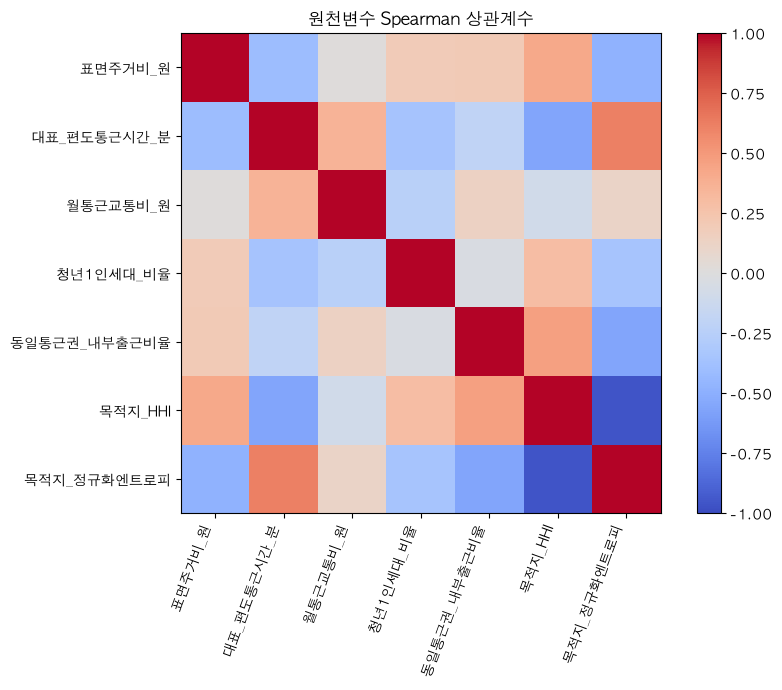

In [13]:

# =========================================================
# 13. 분포 및 상관관계
# =========================================================

display(analysis_data[SOURCE_FEATURES].describe().T)

correlation = analysis_data[SOURCE_FEATURES].corr(
    method="spearman"
)
display(correlation.round(3))

fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(
    correlation,
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)
ax.set_xticks(range(len(correlation.columns)))
ax.set_xticklabels(
    correlation.columns,
    rotation=70,
    ha="right",
)
ax.set_yticks(range(len(correlation.index)))
ax.set_yticklabels(correlation.index)
ax.set_title("원천변수 Spearman 상관계수")
fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()


## 14. 변수 설계

### 최종 후보에 반드시 포함할 두 블록

**부담 블록**
- 표면주거비
- 대표 편도 통근시간
- 월 통근교통비

**통근구조 블록**
- 동일 통근권 내부 출근 비율
- 목적지 정규화 엔트로피

HHI는 엔트로피와 중복 가능성이 있어 6변수 보조모델에서만 함께 사용한다.

`A_핵심부담3`과 `D_통근구조2`는 비교/진단용으로만 계산할 수 있지만,
**최종 shortlist에는 B/C/블록균형/PCA처럼 부담+구조를 모두 포함한 모델만 들어간다.**

청년 1인세대 비율은 계속 사후 프로파일용이다.


In [14]:
# =========================================================
# 14. 변수 블록 및 변수조합 정의
# =========================================================

BURDEN_FEATURES = [
    "표면주거비_원",
    "대표_편도통근시간_분",
    "월통근교통비_원",
]

STRUCTURE_FEATURES = [
    "동일통근권_내부출근비율",
    "목적지_정규화엔트로피",
]

STRUCTURE_FEATURES_WITH_HHI = [
    "동일통근권_내부출근비율",
    "목적지_정규화엔트로피",
    "목적지_HHI",
]

PROFILE_ONLY_FEATURES = [
    "청년1인세대_비율",
]

FEATURE_SETS = {
    "A_핵심부담3_진단용": BURDEN_FEATURES,
    "B_부담+구조5": BURDEN_FEATURES + STRUCTURE_FEATURES,
    "C_부담+구조6_HHI포함": BURDEN_FEATURES + STRUCTURE_FEATURES_WITH_HHI,
    "D_통근구조2_진단용": STRUCTURE_FEATURES,
}

FINAL_ELIGIBLE_FEATURE_SETS = {
    "B_부담+구조5",
    "C_부담+구조6_HHI포함",
    "E_블록균형50_50",
}

for name, features in FEATURE_SETS.items():
    print(name, ":", features)

print("\n[상관관계]")
display(
    analysis_data[
        list(dict.fromkeys(BURDEN_FEATURES + STRUCTURE_FEATURES_WITH_HHI))
    ].corr().round(3)
)


A_핵심부담3_진단용 : ['표면주거비_원', '대표_편도통근시간_분', '월통근교통비_원']
B_부담+구조5 : ['표면주거비_원', '대표_편도통근시간_분', '월통근교통비_원', '동일통근권_내부출근비율', '목적지_정규화엔트로피']
C_부담+구조6_HHI포함 : ['표면주거비_원', '대표_편도통근시간_분', '월통근교통비_원', '동일통근권_내부출근비율', '목적지_정규화엔트로피', '목적지_HHI']
D_통근구조2_진단용 : ['동일통근권_내부출근비율', '목적지_정규화엔트로피']

[상관관계]


,표면주거비_원,대표_편도통근시간_분,월통근교통비_원,동일통근권_내부출근비율,목적지_정규화엔트로피,목적지_HHI
표면주거비_원,1.0000,-0.3750,0.1020,0.2170,-0.4670,0.3660
대표_편도통근시간_분,-0.3750,1.0000,0.1950,-0.2270,0.6690,-0.5280
월통근교통비_원,0.1020,0.1950,1.0000,0.1810,-0.0660,0.0840
동일통근권_내부출근비율,0.2170,-0.2270,0.1810,1.0000,-0.5270,0.3430
목적지_정규화엔트로피,-0.4670,0.6690,-0.0660,-0.5270,1.0000,-0.8860
목적지_HHI,0.3660,-0.5280,0.0840,0.3430,-0.8860,1.0000


## 15. 군집화 가능성 자체 점검

군집분석을 하기 전에 데이터가 정말 군집을 만들 만한 구조인지 본다.

- **Hopkins statistic**: 0.5에 가까우면 거의 무작위, 1에 가까울수록 군집 구조가 존재
- PCA 설명력: 몇 개 잠재축으로 데이터가 요약되는지 확인

이 단계에서 강한 자연군집이 없더라도 분석을 중단하지는 않는다.  
행정동 유형화는 자연적으로 완전히 분리된 종(species)을 찾는 문제가 아니라,
**서비스적으로 의미 있는 상대적 유형 구조**를 찾는 목적도 있기 때문이다.


In [15]:
# =========================================================
# 15. Hopkins statistic + PCA 설명력
# =========================================================

def hopkins_statistic(x, sample_size=None, random_state=42):
    rng = np.random.default_rng(random_state)
    x = np.asarray(x, dtype=float)
    n, d = x.shape

    if sample_size is None:
        sample_size = min(max(30, int(n * 0.1)), n - 1)

    sample_idx = rng.choice(n, size=sample_size, replace=False)
    sample_x = x[sample_idx]

    mins = x.min(axis=0)
    maxs = x.max(axis=0)
    random_x = rng.uniform(mins, maxs, size=(sample_size, d))

    nn = NearestNeighbors(n_neighbors=2).fit(x)
    u_dist, _ = nn.kneighbors(random_x, n_neighbors=1)
    w_dist, _ = nn.kneighbors(sample_x, n_neighbors=2)

    u = u_dist[:, 0]
    w = w_dist[:, 1]

    return float(u.sum() / (u.sum() + w.sum()))

hopkins_rows = []

for feature_set_name, features in FEATURE_SETS.items():
    raw = analysis_data[features].astype(float)

    for scaler_name, scaler in {
        "StandardScaler": StandardScaler(),
        "RobustScaler": RobustScaler(),
    }.items():
        x = scaler.fit_transform(raw)

        hopkins_values = [
            hopkins_statistic(
                x,
                sample_size=min(50, len(x)-1),
                random_state=RANDOM_STATE + r,
            )
            for r in range(20)
        ]

        pca = PCA().fit(x)
        cum = np.cumsum(pca.explained_variance_ratio_)
        pc80 = int(np.argmax(cum >= 0.80) + 1)
        pc90 = int(np.argmax(cum >= 0.90) + 1)

        hopkins_rows.append({
            "변수조합": feature_set_name,
            "스케일러": scaler_name,
            "Hopkins_평균": np.mean(hopkins_values),
            "Hopkins_표준편차": np.std(hopkins_values),
            "80%설명_PC수": pc80,
            "90%설명_PC수": pc90,
            "PC1설명률": pca.explained_variance_ratio_[0],
            "PC1_2설명률": pca.explained_variance_ratio_[:2].sum()
                if len(pca.explained_variance_ratio_) >= 2 else 1.0,
        })

clustering_tendency = pd.DataFrame(hopkins_rows)

display(
    clustering_tendency.sort_values(
        "Hopkins_평균",
        ascending=False,
    )
)

,변수조합,스케일러,Hopkins_평균,Hopkins_표준편차,80%설명_PC수,90%설명_PC수,PC1설명률,PC1_2설명률
5,C_부담+구조6_HHI포함,RobustScaler,0.8874,0.0112,2,3,0.6182,0.8227
4,C_부담+구조6_HHI포함,StandardScaler,0.8761,0.0105,3,4,0.4892,0.6853
1,A_핵심부담3_진단용,RobustScaler,0.8750,0.0238,2,3,0.5667,0.8769
0,A_핵심부담3_진단용,StandardScaler,0.8749,0.0204,2,3,0.4627,0.8233
3,B_부담+구조5,RobustScaler,0.8426,0.0150,3,4,0.4018,0.7735
2,B_부담+구조5,StandardScaler,0.8422,0.0132,3,4,0.4566,0.6919
6,D_통근구조2_진단용,StandardScaler,0.8173,0.0264,2,2,0.7636,1.0000
7,D_통근구조2_진단용,RobustScaler,0.8169,0.0279,1,2,0.8094,1.0000


## 16. 데이터 표현 방식도 비교

알고리즘만 바꾸는 것이 아니라 **입력 표현 자체**도 바꾼다.

- `RAW_STANDARD`: 원변수 StandardScaler
- `RAW_ROBUST`: 원변수 RobustScaler
- `BLOCK_BALANCED`: 부담 블록 50%, 통근구조 블록 50%가 되도록 블록별 가중
- `PCA_90`: 표준화 후 누적설명력 90%까지 PCA 축 사용

즉, 특정 변수의 개수가 많다는 이유만으로 그 영역이 군집을 지배하지 않도록 한다.


In [16]:
# =========================================================
# 16. 다양한 입력 표현 생성
# =========================================================

REPRESENTATIONS = {}

# A/B/C/D 원변수 표현
for feature_set_name, features in FEATURE_SETS.items():
    raw = analysis_data[features].astype(float)

    for scaler_name, scaler in {
        "StandardScaler": StandardScaler(),
        "RobustScaler": RobustScaler(),
    }.items():
        x = scaler.fit_transform(raw)

        REPRESENTATIONS[
            f"{feature_set_name}__{scaler_name}"
        ] = {
            "x": x,
            "원변수": features,
            "표현방식": scaler_name,
            "변수조합": feature_set_name,
            "pca": None,
        }

# 블록 균형형: 부담 전체 50%, 구조 전체 50%
burden_z = StandardScaler().fit_transform(
    analysis_data[BURDEN_FEATURES]
)
structure_z = StandardScaler().fit_transform(
    analysis_data[STRUCTURE_FEATURES]
)

# 각 블록의 전체 제곱가중치 합이 동일하도록 조정
burden_weight = np.sqrt(0.5 / len(BURDEN_FEATURES))
structure_weight = np.sqrt(0.5 / len(STRUCTURE_FEATURES))

x_block = np.column_stack([
    burden_z * burden_weight,
    structure_z * structure_weight,
])

REPRESENTATIONS["E_블록균형50_50"] = {
    "x": x_block,
    "원변수": BURDEN_FEATURES + STRUCTURE_FEATURES,
    "표현방식": "BlockBalanced",
    "변수조합": "E_블록균형50_50",
    "pca": None,
}

# PCA 표현
for feature_set_name in [
    "B_부담+구조5",
    "C_부담+구조6_HHI포함",
]:
    features = FEATURE_SETS[feature_set_name]
    x0 = StandardScaler().fit_transform(
        analysis_data[features]
    )

    pca_full = PCA(random_state=RANDOM_STATE).fit(x0)
    cum = np.cumsum(pca_full.explained_variance_ratio_)
    n_components = int(np.argmax(cum >= 0.90) + 1)

    pca = PCA(
        n_components=n_components,
        random_state=RANDOM_STATE,
    )
    x_pca = pca.fit_transform(x0)

    REPRESENTATIONS[
        f"{feature_set_name}__PCA90"
    ] = {
        "x": x_pca,
        "원변수": features,
        "표현방식": "PCA90",
        "변수조합": feature_set_name,
        "pca": pca,
    }

print("총 입력 표현 수:", len(REPRESENTATIONS))
for key, value in REPRESENTATIONS.items():
    print(
        f"- {key}: shape={value['x'].shape}, "
        f"원변수={len(value['원변수'])}개"
    )

총 입력 표현 수: 11
- A_핵심부담3_진단용__StandardScaler: shape=(427, 3), 원변수=3개
- A_핵심부담3_진단용__RobustScaler: shape=(427, 3), 원변수=3개
- B_부담+구조5__StandardScaler: shape=(427, 5), 원변수=5개
- B_부담+구조5__RobustScaler: shape=(427, 5), 원변수=5개
- C_부담+구조6_HHI포함__StandardScaler: shape=(427, 6), 원변수=6개
- C_부담+구조6_HHI포함__RobustScaler: shape=(427, 6), 원변수=6개
- D_통근구조2_진단용__StandardScaler: shape=(427, 2), 원변수=2개
- D_통근구조2_진단용__RobustScaler: shape=(427, 2), 원변수=2개
- E_블록균형50_50: shape=(427, 5), 원변수=5개
- B_부담+구조5__PCA90: shape=(427, 4), 원변수=5개
- C_부담+구조6_HHI포함__PCA90: shape=(427, 4), 원변수=6개


## 17. 고정 k 알고리즘 대규모 비교

군집 수를 3으로 고정하지 않고 **3~8개**를 모두 비교한다.

사용 알고리즘:
- KMeans
- MiniBatchKMeans
- BisectingKMeans
- KMedoids(설치 시)
- Agglomerative Ward
- Agglomerative Complete
- Agglomerative Average
- Gaussian Mixture: full / diag covariance
- Spectral
- Birch

이 단계에서 수백 개 후보를 만든 뒤 1차 필터를 거친다.


In [17]:
# =========================================================
# 17. 고정 k 알고리즘 정의
# =========================================================

FIXED_K_METHODS = [
    "KMeans",
    "MiniBatchKMeans",
    "BisectingKMeans",
    "Agglomerative_Ward",
    "Agglomerative_Complete",
    "Agglomerative_Average",
    "GMM_full",
    "GMM_diag",
    "Spectral",
    "Birch",
]

if KMEDOIDS_AVAILABLE:
    FIXED_K_METHODS.insert(3, "KMedoids")


def fit_fixed_k_model(method, x, k, random_state=RANDOM_STATE):
    if method == "KMeans":
        model = KMeans(
            n_clusters=k,
            n_init=50,
            random_state=random_state,
        )

    elif method == "MiniBatchKMeans":
        model = MiniBatchKMeans(
            n_clusters=k,
            n_init=30,
            random_state=random_state,
            batch_size=128,
        )

    elif method == "BisectingKMeans":
        model = BisectingKMeans(
            n_clusters=k,
            random_state=random_state,
        )

    elif method == "KMedoids":
        model = KMedoids(
            n_clusters=k,
            metric="euclidean",
            method="pam",
            init="k-medoids++",
            random_state=random_state,
        )

    elif method == "Agglomerative_Ward":
        model = AgglomerativeClustering(
            n_clusters=k,
            linkage="ward",
        )

    elif method == "Agglomerative_Complete":
        model = AgglomerativeClustering(
            n_clusters=k,
            linkage="complete",
        )

    elif method == "Agglomerative_Average":
        model = AgglomerativeClustering(
            n_clusters=k,
            linkage="average",
        )

    elif method == "GMM_full":
        model = GaussianMixture(
            n_components=k,
            covariance_type="full",
            n_init=20,
            reg_covar=1e-6,
            random_state=random_state,
        )

    elif method == "GMM_diag":
        model = GaussianMixture(
            n_components=k,
            covariance_type="diag",
            n_init=20,
            reg_covar=1e-6,
            random_state=random_state,
        )

    elif method == "Spectral":
        model = SpectralClustering(
            n_clusters=k,
            affinity="nearest_neighbors",
            n_neighbors=min(15, len(x)-1),
            assign_labels="kmeans",
            n_init=20,
            random_state=random_state,
        )

    elif method == "Birch":
        model = Birch(
            n_clusters=k,
            threshold=0.5,
        )

    else:
        raise ValueError(method)

    labels = model.fit_predict(x)
    return model, labels


def safe_internal_scores(x, labels):
    labels = np.asarray(labels)
    valid = labels >= 0
    unique = np.unique(labels[valid])

    if valid.sum() < 10 or len(unique) < 2:
        return {
            "Silhouette": np.nan,
            "Calinski_Harabasz": np.nan,
            "Davies_Bouldin": np.nan,
        }

    xv = x[valid]
    lv = labels[valid]

    if len(np.unique(lv)) >= len(xv):
        return {
            "Silhouette": np.nan,
            "Calinski_Harabasz": np.nan,
            "Davies_Bouldin": np.nan,
        }

    return {
        "Silhouette": silhouette_score(xv, lv),
        "Calinski_Harabasz": calinski_harabasz_score(xv, lv),
        "Davies_Bouldin": davies_bouldin_score(xv, lv),
    }


def cluster_balance(labels):
    labels = pd.Series(labels)
    clustered = labels[labels >= 0]
    counts = clustered.value_counts()

    if len(counts) == 0:
        return {
            "최소군집크기": 0,
            "최대군집크기": 0,
            "최소군집비율": 0,
            "최대군집비율": 1,
            "군집균형엔트로피": 0,
            "노이즈비율": 1.0,
            "실제군집수": 0,
        }

    proportions = counts / counts.sum()

    entropy = (
        -(proportions * np.log(proportions)).sum()
        / np.log(len(proportions))
        if len(proportions) > 1 else 0
    )

    return {
        "최소군집크기": int(counts.min()),
        "최대군집크기": int(counts.max()),
        "최소군집비율": float(proportions.min()),
        "최대군집비율": float(proportions.max()),
        "군집균형엔트로피": float(entropy),
        "노이즈비율": float((labels < 0).mean()),
        "실제군집수": int(len(counts)),
    }


def profile_separation_score(labels):
    """원단위 주요 지표에서 군집 평균이 서울 평균 대비 얼마나 분리되는지."""
    temp = analysis_data[
        BURDEN_FEATURES + STRUCTURE_FEATURES
    ].copy()
    temp["_cluster"] = labels

    temp = temp[temp["_cluster"] >= 0]
    if temp["_cluster"].nunique() < 2:
        return np.nan

    z = (
        temp[BURDEN_FEATURES + STRUCTURE_FEATURES]
        - analysis_data[BURDEN_FEATURES + STRUCTURE_FEATURES].mean()
    ) / analysis_data[BURDEN_FEATURES + STRUCTURE_FEATURES].std(ddof=0)

    z["_cluster"] = temp["_cluster"].values
    centers = z.groupby("_cluster").mean().to_numpy()

    if len(centers) < 2:
        return np.nan

    d = pairwise_distances(centers)
    vals = d[np.triu_indices_from(d, k=1)]
    return float(np.mean(vals))

In [18]:
# =========================================================
# 18. 고정 k 후보 전체 실행
# =========================================================

fixed_rows = []
fixed_models = {}

for rep_name, rep in REPRESENTATIONS.items():
    x = rep["x"]

    for method in FIXED_K_METHODS:
        for k in K_VALUES:
            try:
                model, labels = fit_fixed_k_model(
                    method, x, k
                )
                scores = safe_internal_scores(x, labels)
                balance = cluster_balance(labels)

                row = {
                    "표현": rep_name,
                    "변수조합": rep["변수조합"],
                    "표현방식": rep["표현방식"],
                    "방법": method,
                    "요청군집수": k,
                    **scores,
                    **balance,
                    "프로파일분리도": profile_separation_score(labels),
                }
                fixed_rows.append(row)

                fixed_models[
                    (rep_name, method, k)
                ] = {
                    "model": model,
                    "labels": labels,
                    "x": x,
                    "rep": rep,
                }

            except Exception as e:
                print("실패:", rep_name, method, k, repr(e))

fixed_scores = pd.DataFrame(fixed_rows)

print("고정 k 후보 수:", len(fixed_scores))
display(
    fixed_scores.sort_values(
        ["Silhouette", "프로파일분리도"],
        ascending=[False, False],
    ).head(40)
)

고정 k 후보 수: 550


,표현,변수조합,표현방식,방법,요청군집수,Silhouette,Calinski_Harabasz,Davies_Bouldin,최소군집크기,최대군집크기,최소군집비율,최대군집비율,군집균형엔트로피,노이즈비율,실제군집수,프로파일분리도
275,C_부담+구조6_HHI포함__RobustScaler,C_부담+구조6_HHI포함,RobustScaler,Agglomerative_Average,4,0.7143,105.4218,0.4299,1,415,0.0023,0.9719,0.1039,0.0000,4,7.4422
276,C_부담+구조6_HHI포함__RobustScaler,C_부담+구조6_HHI포함,RobustScaler,Agglomerative_Average,5,0.7018,84.0990,0.3873,1,415,0.0023,0.9719,0.0942,0.0000,5,7.4648
225,C_부담+구조6_HHI포함__StandardScaler,C_부담+구조6_HHI포함,StandardScaler,Agglomerative_Average,4,0.6538,39.9869,0.3830,1,420,0.0023,0.9836,0.0698,0.0000,4,8.4397
525,C_부담+구조6_HHI포함__PCA90,C_부담+구조6_HHI포함,PCA90,Agglomerative_Average,4,0.6529,40.9376,0.3443,1,420,0.0023,0.9836,0.0698,0.0000,4,8.4397
277,C_부담+구조6_HHI포함__RobustScaler,C_부담+구조6_HHI포함,RobustScaler,Agglomerative_Average,6,0.6486,72.1312,0.3641,1,415,0.0023,0.9719,0.0921,0.0000,6,6.8670
75,A_핵심부담3_진단용__RobustScaler,A_핵심부담3_진단용,RobustScaler,Agglomerative_Average,4,0.6357,62.8076,0.2921,1,420,0.0023,0.9836,0.0698,0.0000,4,8.0633
170,B_부담+구조5__RobustScaler,B_부담+구조5,RobustScaler,Agglomerative_Complete,4,0.5455,40.8265,0.3512,1,420,0.0023,0.9836,0.0698,0.0000,4,8.0633
175,B_부담+구조5__RobustScaler,B_부담+구조5,RobustScaler,Agglomerative_Average,4,0.5452,43.5463,0.4881,1,419,0.0023,0.9813,0.0793,0.0000,4,7.6038
76,A_핵심부담3_진단용__RobustScaler,A_핵심부담3_진단용,RobustScaler,Agglomerative_Average,5,0.5391,58.5418,0.3252,1,416,0.0023,0.9742,0.0930,0.0000,5,7.8010
25,A_핵심부담3_진단용__StandardScaler,A_핵심부담3_진단용,StandardScaler,Agglomerative_Average,4,0.5389,35.8511,0.3654,1,420,0.0023,0.9836,0.0698,0.0000,4,8.0633


## 19. 군집 수를 자동으로 정하는 알고리즘 비교

고정 k 방식만 비교하면 분석자가 미리 군집 수 범위를 정했다는 한계가 있다.  
따라서 **밀도 기반/자동 군집 수 방식**도 별도 비교한다.

- DBSCAN: eps 후보를 k-distance 분위수로 생성
- OPTICS
- HDBSCAN(현재 sklearn 버전 지원 시)
- MeanShift
- AffinityPropagation

이 계열은 일부 행정동을 `noise(-1)`로 판단할 수 있다.  
노이즈가 너무 많거나 군집이 너무 작은 결과는 최종 후보에서 제외한다.


In [19]:
# =========================================================
# 19. 자동 군집 알고리즘
# =========================================================

auto_rows = []
auto_models = {}

# 계산량 때문에 핵심 4개 표현에서만 수행
AUTO_REP_NAMES = [
    name for name in REPRESENTATIONS
    if (
        name.startswith("B_부담+구조5")
        or name == "E_블록균형50_50"
        or name.startswith("C_부담+구조6_HHI포함__PCA90")
    )
]

for rep_name in AUTO_REP_NAMES:
    rep = REPRESENTATIONS[rep_name]
    x = rep["x"]

    # DBSCAN eps 후보: 5-NN 거리 분위수
    nn = NearestNeighbors(n_neighbors=min(6, len(x))).fit(x)
    dist, _ = nn.kneighbors(x)
    kth = dist[:, -1]

    eps_values = np.unique(
        np.quantile(kth, [0.70, 0.75, 0.80, 0.85, 0.90])
    )

    auto_specs = []

    for eps in eps_values:
        auto_specs.append((
            f"DBSCAN_eps{eps:.3f}",
            DBSCAN(
                eps=float(eps),
                min_samples=5,
            ),
        ))

    auto_specs += [
        (
            "OPTICS",
            OPTICS(
                min_samples=5,
                min_cluster_size=0.05,
                xi=0.05,
            ),
        ),
        (
            "AffinityPropagation",
            AffinityPropagation(
                random_state=RANDOM_STATE,
                damping=0.85,
            ),
        ),
    ]

    bandwidth = estimate_bandwidth(
        x,
        quantile=0.20,
        n_samples=min(300, len(x)),
        random_state=RANDOM_STATE,
    )
    if bandwidth and np.isfinite(bandwidth) and bandwidth > 0:
        auto_specs.append((
            "MeanShift",
            MeanShift(
                bandwidth=bandwidth,
                bin_seeding=True,
            ),
        ))

    if HDBSCAN_AVAILABLE:
        auto_specs.append((
            "HDBSCAN",
            HDBSCAN(
                min_cluster_size=20,
                min_samples=5,
            ),
        ))

    for method_name, model in auto_specs:
        try:
            labels = model.fit_predict(x)
            scores = safe_internal_scores(x, labels)
            balance = cluster_balance(labels)

            auto_rows.append({
                "표현": rep_name,
                "변수조합": rep["변수조합"],
                "표현방식": rep["표현방식"],
                "방법": method_name,
                "요청군집수": np.nan,
                **scores,
                **balance,
                "프로파일분리도": profile_separation_score(labels),
            })

            auto_models[
                (rep_name, method_name)
            ] = {
                "model": model,
                "labels": labels,
                "x": x,
                "rep": rep,
            }

        except Exception as e:
            print("자동군집 실패:", rep_name, method_name, repr(e))

auto_scores = pd.DataFrame(auto_rows)

display(
    auto_scores.sort_values(
        ["Silhouette", "프로파일분리도"],
        ascending=[False, False],
    ).head(40)
)

,표현,변수조합,표현방식,방법,요청군집수,Silhouette,Calinski_Harabasz,Davies_Bouldin,최소군집크기,최대군집크기,최소군집비율,최대군집비율,군집균형엔트로피,노이즈비율,실제군집수,프로파일분리도
44,C_부담+구조6_HHI포함__PCA90,C_부담+구조6_HHI포함,PCA90,HDBSCAN,NaN,0.5897,137.3201,0.6049,29,29,0.5000,0.5000,1.0000,0.8642,2,1.7597
29,B_부담+구조5__PCA90,B_부담+구조5,PCA90,DBSCAN_eps0.982,NaN,0.4943,28.1905,0.4701,4,385,0.0103,0.9897,0.0827,0.0890,2,4.7944
26,E_블록균형50_50,E_블록균형50_50,BlockBalanced,HDBSCAN,NaN,0.4678,139.1070,0.8273,52,57,0.4771,0.5229,0.9985,0.7447,2,1.7669
35,B_부담+구조5__PCA90,B_부담+구조5,PCA90,HDBSCAN,NaN,0.4509,86.6386,0.8557,31,52,0.3735,0.6265,0.9533,0.8056,2,1.6404
8,B_부담+구조5__StandardScaler,B_부담+구조5,StandardScaler,HDBSCAN,NaN,0.4353,105.6677,0.9169,46,57,0.4466,0.5534,0.9918,0.7588,2,1.7558
19,E_블록균형50_50,E_블록균형50_50,BlockBalanced,DBSCAN_eps0.447,NaN,0.4063,72.6761,0.7166,16,370,0.0415,0.9585,0.2489,0.0960,2,3.7101
1,B_부담+구조5__StandardScaler,B_부담+구조5,StandardScaler,DBSCAN_eps1.040,NaN,0.3972,73.6772,0.7336,17,368,0.0442,0.9558,0.2610,0.0984,2,3.6926
37,C_부담+구조6_HHI포함__PCA90,C_부담+구조6_HHI포함,PCA90,DBSCAN_eps0.917,NaN,0.3961,45.4340,0.6276,10,361,0.0270,0.9730,0.1789,0.1311,2,3.3292
36,C_부담+구조6_HHI포함__PCA90,C_부담+구조6_HHI포함,PCA90,DBSCAN_eps0.829,NaN,0.3912,40.4763,0.6166,9,350,0.0251,0.9749,0.1690,0.1593,2,3.2532
20,E_블록균형50_50,E_블록균형50_50,BlockBalanced,DBSCAN_eps0.484,NaN,0.3890,71.7165,0.7408,17,379,0.0429,0.9571,0.2556,0.0726,2,3.6471


## 20. Fuzzy C-Means

경계가 명확하지 않은 행정동 유형에는 퍼지 군집이 오히려 자연스러울 수 있다.

Fuzzy C-Means가 설치되어 있으면:
- k=3~8
- 퍼지계수 m=1.5 / 2.0

을 비교하고,
- FPC
- 평균 최대 소속확률
- 낮은 확신도 비율
- hard assignment 기준 Silhouette

을 함께 본다.


In [20]:
# =========================================================
# 20. Fuzzy C-Means
# =========================================================

fuzzy_rows = []
fuzzy_models = {}

if FUZZY_AVAILABLE:
    FUZZY_REP_NAMES = [
        name for name in REPRESENTATIONS
        if (
            name.startswith("B_부담+구조5__RobustScaler")
            or name == "E_블록균형50_50"
        )
    ]

    for rep_name in FUZZY_REP_NAMES:
        x = REPRESENTATIONS[rep_name]["x"]

        for k in K_VALUES:
            for m in [1.5, 2.0]:
                cntr, u, _, _, _, _, fpc = fuzz.cluster.cmeans(
                    x.T,
                    c=k,
                    m=m,
                    error=0.005,
                    maxiter=1000,
                    init=None,
                    seed=RANDOM_STATE,
                )

                labels = np.argmax(u, axis=0)
                max_prob = np.max(u, axis=0)

                scores = safe_internal_scores(x, labels)
                balance = cluster_balance(labels)

                fuzzy_rows.append({
                    "표현": rep_name,
                    "변수조합": REPRESENTATIONS[rep_name]["변수조합"],
                    "표현방식": REPRESENTATIONS[rep_name]["표현방식"],
                    "방법": f"FuzzyCMeans_m{m}",
                    "요청군집수": k,
                    **scores,
                    **balance,
                    "프로파일분리도": profile_separation_score(labels),
                    "FPC": fpc,
                    "평균최대소속확률": max_prob.mean(),
                    "소속확률0.6미만비율": (max_prob < 0.6).mean(),
                })

                fuzzy_models[
                    (rep_name, f"FuzzyCMeans_m{m}", k)
                ] = {
                    "centers": cntr,
                    "membership": u,
                    "labels": labels,
                    "x": x,
                    "rep": REPRESENTATIONS[rep_name],
                }

    fuzzy_scores = pd.DataFrame(fuzzy_rows)
    display(
        fuzzy_scores.sort_values(
            ["FPC", "Silhouette"],
            ascending=False,
        ).head(30)
    )

else:
    fuzzy_scores = pd.DataFrame()
    print("skfuzzy가 없어 Fuzzy C-Means는 건너뜁니다.")

,표현,변수조합,표현방식,방법,요청군집수,Silhouette,Calinski_Harabasz,Davies_Bouldin,최소군집크기,최대군집크기,최소군집비율,최대군집비율,군집균형엔트로피,노이즈비율,실제군집수,프로파일분리도,FPC,평균최대소속확률,소속확률0.6미만비율
10,E_블록균형50_50,E_블록균형50_50,BlockBalanced,FuzzyCMeans_m1.5,4,0.2368,142.8813,1.4218,41,142,0.0960,0.3326,0.9408,0.0000,4,2.7825,0.6645,0.7641,0.2342
0,B_부담+구조5__RobustScaler,B_부담+구조5,RobustScaler,FuzzyCMeans_m1.5,4,0.2108,119.3910,1.3364,52,177,0.1218,0.4145,0.9030,0.0000,4,2.7554,0.6501,0.7519,0.2295
12,E_블록균형50_50,E_블록균형50_50,BlockBalanced,FuzzyCMeans_m1.5,5,0.2356,132.4409,1.3077,35,128,0.0820,0.2998,0.9458,0.0000,5,2.7717,0.6235,0.7368,0.2670
2,B_부담+구조5__RobustScaler,B_부담+구조5,RobustScaler,FuzzyCMeans_m1.5,5,0.2031,109.6149,1.3456,34,130,0.0796,0.3044,0.9272,0.0000,5,2.8522,0.6095,0.7230,0.2810
14,E_블록균형50_50,E_블록균형50_50,BlockBalanced,FuzzyCMeans_m1.5,6,0.2229,127.3318,1.3009,32,117,0.0749,0.2740,0.9627,0.0000,6,2.8644,0.6069,0.7229,0.2998
6,B_부담+구조5__RobustScaler,B_부담+구조5,RobustScaler,FuzzyCMeans_m1.5,7,0.2183,119.8597,1.2087,6,115,0.0141,0.2693,0.9059,0.0000,7,3.6405,0.5933,0.7142,0.3138
4,B_부담+구조5__RobustScaler,B_부담+구조5,RobustScaler,FuzzyCMeans_m1.5,6,0.2013,102.6187,1.2902,32,123,0.0749,0.2881,0.9469,0.0000,6,2.8825,0.5876,0.7088,0.3068
16,E_블록균형50_50,E_블록균형50_50,BlockBalanced,FuzzyCMeans_m1.5,7,0.1931,117.1749,1.3867,31,77,0.0726,0.1803,0.9827,0.0000,7,2.7675,0.5701,0.6972,0.3279
8,B_부담+구조5__RobustScaler,B_부담+구조5,RobustScaler,FuzzyCMeans_m1.5,8,0.1981,109.2234,1.3197,6,89,0.0141,0.2084,0.9279,0.0000,8,3.4052,0.5572,0.6833,0.3747
18,E_블록균형50_50,E_블록균형50_50,BlockBalanced,FuzzyCMeans_m1.5,8,0.1825,109.0507,1.3421,25,74,0.0585,0.1733,0.9789,0.0000,8,2.7603,0.5435,0.6730,0.3934


## 21. 후보 통합 및 1차 필터

이번에는 최종 후보의 **군집 개수와 군집 크기를 강하게 제한**한다.

### 엄격 기준
- 군집 수: 4~8
- 최소 군집: 30개 이상
- 최대 군집: 전체의 38% 이하
- 노이즈: 10% 이하

엄격 기준 후보가 너무 적을 때만 보조적으로:
- 최소 20개
- 최대 45%

까지 완화한다.

그리고 전체 점수 상위 30개를 단순히 자르지 않고,
**변수조합 × 군집수별로 상위 후보를 균등하게 남긴다.**


In [21]:
# =========================================================
# 21. 후보 통합 / 엄격 크기 필터 / 균형 shortlist 준비
# =========================================================

all_candidates = pd.concat(
    [
        fixed_scores.assign(후보계열="고정k"),
        auto_scores.assign(후보계열="자동군집"),
        (
            fuzzy_scores.assign(후보계열="퍼지")
            if len(fuzzy_scores)
            else pd.DataFrame()
        ),
    ],
    ignore_index=True,
    sort=False,
)

# 최종 후보는 부담+통근구조가 함께 들어간 표현만
def is_final_eligible_rep(row):
    name = str(row["변수조합"])
    rep = str(row["표현"])
    return (
        name in {"B_부담+구조5", "C_부담+구조6_HHI포함", "E_블록균형50_50"}
        or "B_부담+구조5" in rep
        or "C_부담+구조6_HHI포함" in rep
        or rep == "E_블록균형50_50"
    )

all_candidates["종합변수모델"] = all_candidates.apply(
    is_final_eligible_rep,
    axis=1,
)

all_candidates["엄격적격"] = (
    all_candidates["종합변수모델"]
    & all_candidates["실제군집수"].between(4, 8)
    & (all_candidates["최소군집크기"] >= 30)
    & (all_candidates["최대군집비율"] <= 0.38)
    & (all_candidates["노이즈비율"] <= 0.10)
    & all_candidates["Silhouette"].notna()
    & all_candidates["Davies_Bouldin"].notna()
    & all_candidates["프로파일분리도"].notna()
)

all_candidates["완화적격"] = (
    all_candidates["종합변수모델"]
    & all_candidates["실제군집수"].between(4, 8)
    & (all_candidates["최소군집크기"] >= 20)
    & (all_candidates["최대군집비율"] <= 0.45)
    & (all_candidates["노이즈비율"] <= 0.15)
    & all_candidates["Silhouette"].notna()
    & all_candidates["Davies_Bouldin"].notna()
    & all_candidates["프로파일분리도"].notna()
)

eligible = all_candidates[
    all_candidates["엄격적격"]
].copy()

if len(eligible) < 15:
    print("엄격 적격 후보가 15개 미만이라 완화 기준을 사용합니다.")
    eligible = all_candidates[
        all_candidates["완화적격"]
    ].copy()

def minmax(s):
    s = pd.to_numeric(s, errors="coerce")
    if s.notna().sum() == 0 or s.max() == s.min():
        return pd.Series(0.5, index=s.index)
    return (s - s.min()) / (s.max() - s.min())

eligible["점수_Silhouette"] = minmax(eligible["Silhouette"])
eligible["점수_CH"] = minmax(np.log1p(eligible["Calinski_Harabasz"]))
eligible["점수_DB"] = 1 - minmax(eligible["Davies_Bouldin"])
eligible["점수_균형"] = minmax(eligible["군집균형엔트로피"])
eligible["점수_프로파일분리"] = minmax(eligible["프로파일분리도"])

# '잘 갈리는가'보다 '의미가 다르고 크기가 적절한가' 비중을 크게
eligible["1차분석점수"] = (
    0.15 * eligible["점수_Silhouette"]
    + 0.10 * eligible["점수_CH"]
    + 0.10 * eligible["점수_DB"]
    + 0.30 * eligible["점수_균형"]
    + 0.35 * eligible["점수_프로파일분리"]
)

print("전체 후보:", len(all_candidates))
print("엄격 적격:", int(all_candidates["엄격적격"].sum()))
print("완화 적격:", int(all_candidates["완화적격"].sum()))
print("최종 1차 적격:", len(eligible))

display(
    eligible.sort_values(
        ["실제군집수", "1차분석점수"],
        ascending=[True, False],
    ).head(80)
)


전체 후보: 615
엄격 적격: 46
완화 적격: 97
최종 1차 적격: 46


,표현,변수조합,표현방식,방법,요청군집수,Silhouette,Calinski_Harabasz,Davies_Bouldin,최소군집크기,최대군집크기,최소군집비율,최대군집비율,군집균형엔트로피,노이즈비율,실제군집수,프로파일분리도,후보계열,FPC,평균최대소속확률,소속확률0.6미만비율,종합변수모델,엄격적격,완화적격,점수_Silhouette,점수_CH,점수_DB,점수_균형,점수_프로파일분리,1차분석점수
400,E_블록균형50_50,E_블록균형50_50,BlockBalanced,KMeans,4.0000,0.2504,144.7006,1.3815,35,158,0.0820,0.3700,0.9198,0.0000,4,2.8959,고정k,NaN,NaN,NaN,True,True,True,1.0000,1.0000,0.6686,0.1060,0.8116,0.6327
605,E_블록균형50_50,E_블록균형50_50,BlockBalanced,FuzzyCMeans_m1.5,4.0000,0.2368,142.8813,1.4218,41,142,0.0960,0.3326,0.9408,0.0000,4,2.7825,퍼지,0.6645,0.7641,0.2342,True,True,True,0.8964,0.9789,0.5880,0.3933,0.6124,0.6235
405,E_블록균형50_50,E_블록균형50_50,BlockBalanced,MiniBatchKMeans,4.0000,0.2439,142.1311,1.4592,34,155,0.0796,0.3630,0.9198,0.0000,4,2.8815,고정k,NaN,NaN,NaN,True,True,True,0.9505,0.9701,0.5132,0.1056,0.7862,0.5978
290,C_부담+구조6_HHI포함__RobustScaler,C_부담+구조6_HHI포함,RobustScaler,Spectral,4.0000,0.1848,137.3958,1.4084,43,136,0.1007,0.3185,0.9466,0.0000,4,2.7455,고정k,NaN,NaN,NaN,True,True,True,0.5014,0.9137,0.6147,0.4722,0.5474,0.5613
110,B_부담+구조5__StandardScaler,B_부담+구조5,StandardScaler,BisectingKMeans,4.0000,0.1987,112.4951,1.5040,30,155,0.0703,0.3630,0.9154,0.0000,4,2.9600,고정k,NaN,NaN,NaN,True,True,True,0.6071,0.5807,0.4237,0.0463,0.9241,0.5289
606,E_블록균형50_50,E_블록균형50_50,BlockBalanced,FuzzyCMeans_m2.0,4.0000,0.2020,133.7461,1.5277,65,136,0.1522,0.3185,0.9771,0.0000,4,2.4835,퍼지,0.3967,0.5249,0.7354,True,True,True,0.6318,0.8688,0.3763,0.8902,0.0873,0.5169
460,B_부담+구조5__PCA90,B_부담+구조5,PCA90,BisectingKMeans,4.0000,0.2120,122.1610,1.5412,45,144,0.1054,0.3372,0.9460,0.0000,4,2.6235,고정k,NaN,NaN,NaN,True,True,True,0.7078,0.7179,0.3492,0.4642,0.3331,0.4687
190,B_부담+구조5__RobustScaler,B_부담+구조5,RobustScaler,Spectral,4.0000,0.1893,109.4085,1.3748,66,158,0.1546,0.3700,0.9622,0.0000,4,2.5204,고정k,NaN,NaN,NaN,True,True,True,0.5355,0.5344,0.6819,0.6867,0.1520,0.4612
596,B_부담+구조5__RobustScaler,B_부담+구조5,RobustScaler,FuzzyCMeans_m2.0,4.0000,0.1713,109.6119,1.4022,70,133,0.1639,0.3115,0.9769,0.0000,4,2.4338,퍼지,0.3796,0.5135,0.7377,True,True,True,0.3986,0.5375,0.6273,0.8870,0.0000,0.4424
435,E_블록균형50_50,E_블록균형50_50,BlockBalanced,GMM_diag,4.0000,0.1753,107.5551,1.5175,70,146,0.1639,0.3419,0.9757,0.0000,4,2.4473,고정k,NaN,NaN,NaN,True,True,True,0.4289,0.5060,0.3966,0.8712,0.0236,0.4242


## 22. 반복표본 안정성

shortlist는 이제 전체 점수순 30개가 아니다.

**변수조합/표현 × 군집수별 상위 2개씩** 남긴다.
따라서 4·5·6·7·8개 군집과 여러 변수표현이 모두 심화검증에 들어간다.


In [22]:
# =========================================================
# 22. 반복표본 안정성
# =========================================================

# 표현 × 실제군집수별 상위 2개를 남겨 특정 단순모형 독식 방지
shortlist = (
    eligible.sort_values("1차분석점수", ascending=False)
    .groupby(["표현", "실제군집수"], group_keys=False)
    .head(2)
    .reset_index(drop=True)
)

print("균형 shortlist 수:", len(shortlist))
display(
    shortlist[
        [
            "표현", "방법", "후보계열", "실제군집수",
            "최소군집크기", "최대군집비율",
            "Silhouette", "프로파일분리도",
            "군집균형엔트로피", "1차분석점수"
        ]
    ].sort_values(["실제군집수", "1차분석점수"], ascending=[True, False])
)

def get_candidate_labels(row):
    rep_name = row["표현"]
    method = row["방법"]

    if row["후보계열"] == "고정k":
        key = (
            rep_name,
            method,
            int(row["요청군집수"]),
        )
        return fixed_models[key]["x"], fixed_models[key]["labels"]

    if row["후보계열"] == "자동군집":
        key = (rep_name, method)
        return auto_models[key]["x"], auto_models[key]["labels"]

    if row["후보계열"] == "퍼지":
        key = (
            rep_name,
            method,
            int(row["요청군집수"]),
        )
        return fuzzy_models[key]["x"], fuzzy_models[key]["labels"]

    raise ValueError(row["후보계열"])


def refit_candidate(row, x_subset, seed):
    method = row["방법"]

    if row["후보계열"] == "고정k":
        _, labels = fit_fixed_k_model(
            method,
            x_subset,
            int(row["요청군집수"]),
            random_state=seed,
        )
        return labels

    if row["후보계열"] == "퍼지":
        m = float(method.split("m")[-1])
        k = int(row["요청군집수"])
        _, u, _, _, _, _, _ = fuzz.cluster.cmeans(
            x_subset.T,
            c=k,
            m=m,
            error=0.005,
            maxiter=1000,
            init=None,
            seed=seed,
        )
        return np.argmax(u, axis=0)

    # 자동군집은 같은 하이퍼파라미터 재생성이 복잡하므로
    # 안정성 검증에서는 고정k/퍼지를 우선 사용하고 NaN 처리
    return None


rng = np.random.default_rng(RANDOM_STATE)
stability_rows = []

for _, row in shortlist.iterrows():
    full_x, full_labels = get_candidate_labels(row)

    ari_values = []

    for repeat in range(BOOTSTRAP_REPEATS):
        sample_idx = np.sort(
            rng.choice(
                len(full_x),
                size=int(len(full_x) * BOOTSTRAP_FRACTION),
                replace=False,
            )
        )

        sample_x = full_x[sample_idx]

        try:
            sample_labels = refit_candidate(
                row,
                sample_x,
                RANDOM_STATE + repeat + 1,
            )

            if sample_labels is None:
                ari_values.append(np.nan)
            else:
                ari_values.append(
                    adjusted_rand_score(
                        full_labels[sample_idx],
                        sample_labels,
                    )
                )

        except Exception:
            ari_values.append(np.nan)

    a = np.asarray(ari_values, dtype=float)

    stability_rows.append({
        "표현": row["표현"],
        "방법": row["방법"],
        "요청군집수": row["요청군집수"],
        "후보계열": row["후보계열"],
        "안정성_평균ARI": np.nanmean(a) if np.isfinite(a).any() else np.nan,
        "안정성_하위10%ARI": np.nanquantile(a, 0.10)
            if np.isfinite(a).any() else np.nan,
        "안정성_표준편차": np.nanstd(a)
            if np.isfinite(a).any() else np.nan,
        "성공반복수": int(np.isfinite(a).sum()),
    })

stability = pd.DataFrame(stability_rows)

shortlist = shortlist.merge(
    stability,
    on=["표현", "방법", "요청군집수", "후보계열"],
    how="left",
)

display(
    shortlist.sort_values(
        "안정성_평균ARI",
        ascending=False,
    )
)


균형 shortlist 수: 35


,표현,방법,후보계열,실제군집수,최소군집크기,최대군집비율,Silhouette,프로파일분리도,군집균형엔트로피,1차분석점수
8,E_블록균형50_50,KMeans,고정k,4,35,0.3700,0.2504,2.8959,0.9198,0.6327
9,E_블록균형50_50,FuzzyCMeans_m1.5,퍼지,4,41,0.3326,0.2368,2.7825,0.9408,0.6235
15,C_부담+구조6_HHI포함__RobustScaler,Spectral,고정k,4,43,0.3185,0.1848,2.7455,0.9466,0.5613
22,B_부담+구조5__StandardScaler,BisectingKMeans,고정k,4,30,0.3630,0.1987,2.9600,0.9154,0.5289
29,B_부담+구조5__PCA90,BisectingKMeans,고정k,4,45,0.3372,0.2120,2.6235,0.9460,0.4687
30,B_부담+구조5__RobustScaler,Spectral,고정k,4,66,0.3700,0.1893,2.5204,0.9622,0.4612
31,B_부담+구조5__RobustScaler,FuzzyCMeans_m2.0,퍼지,4,70,0.3115,0.1713,2.4338,0.9769,0.4424
33,B_부담+구조5__StandardScaler,GMM_diag,고정k,4,70,0.3419,0.1622,2.4473,0.9757,0.3829
5,E_블록균형50_50,MiniBatchKMeans,고정k,5,32,0.2998,0.2385,2.8300,0.9387,0.6562
6,E_블록균형50_50,FuzzyCMeans_m1.5,퍼지,5,35,0.2998,0.2356,2.7717,0.9458,0.6462


,표현,변수조합,표현방식,방법,요청군집수,Silhouette,Calinski_Harabasz,Davies_Bouldin,최소군집크기,최대군집크기,최소군집비율,최대군집비율,군집균형엔트로피,노이즈비율,실제군집수,프로파일분리도,후보계열,FPC,평균최대소속확률,소속확률0.6미만비율,종합변수모델,엄격적격,완화적격,점수_Silhouette,점수_CH,점수_DB,점수_균형,점수_프로파일분리,1차분석점수,안정성_평균ARI,안정성_하위10%ARI,안정성_표준편차,성공반복수
9,E_블록균형50_50,E_블록균형50_50,BlockBalanced,FuzzyCMeans_m1.5,4.0000,0.2368,142.8813,1.4218,41,142,0.0960,0.3326,0.9408,0.0000,4,2.7825,퍼지,0.6645,0.7641,0.2342,True,True,True,0.8964,0.9789,0.5880,0.3933,0.6124,0.6235,0.9301,0.8978,0.0829,30
0,E_블록균형50_50,E_블록균형50_50,BlockBalanced,FuzzyCMeans_m1.5,6.0000,0.2229,127.3318,1.3009,32,117,0.0749,0.2740,0.9627,0.0000,6,2.8644,퍼지,0.6069,0.7229,0.2998,True,True,True,0.7912,0.7869,0.8297,0.6927,0.7563,0.7528,0.9064,0.8662,0.0487,30
14,C_부담+구조6_HHI포함__RobustScaler,C_부담+구조6_HHI포함,RobustScaler,Spectral,6.0000,0.1646,107.0988,1.2976,43,115,0.1007,0.2693,0.9697,0.0000,6,2.6743,고정k,NaN,NaN,NaN,True,True,True,0.3476,0.4989,0.8363,0.7885,0.4223,0.5700,0.8698,0.8002,0.0515,30
8,E_블록균형50_50,E_블록균형50_50,BlockBalanced,KMeans,4.0000,0.2504,144.7006,1.3815,35,158,0.0820,0.3700,0.9198,0.0000,4,2.8959,고정k,NaN,NaN,NaN,True,True,True,1.0000,1.0000,0.6686,0.1060,0.8116,0.6327,0.8523,0.5889,0.1341,30
24,B_부담+구조5__RobustScaler,B_부담+구조5,RobustScaler,FuzzyCMeans_m2.0,7.0000,0.1589,89.2807,1.4179,36,77,0.0843,0.1803,0.9813,0.0000,7,2.6109,퍼지,0.2568,0.3902,0.9063,True,True,True,0.3045,0.1966,0.5958,0.9476,0.3110,0.5180,0.8504,0.7067,0.1072,30
3,E_블록균형50_50,E_블록균형50_50,BlockBalanced,FuzzyCMeans_m1.5,7.0000,0.1931,117.1749,1.3867,31,77,0.0726,0.1803,0.9827,0.0000,7,2.7675,퍼지,0.5701,0.6972,0.3279,True,True,True,0.5646,0.6485,0.6581,0.9666,0.5861,0.7105,0.8473,0.7171,0.0916,30
30,B_부담+구조5__RobustScaler,B_부담+구조5,RobustScaler,Spectral,4.0000,0.1893,109.4085,1.3748,66,158,0.1546,0.3700,0.9622,0.0000,4,2.5204,고정k,NaN,NaN,NaN,True,True,True,0.5355,0.5344,0.6819,0.6867,0.1520,0.4612,0.8464,0.7774,0.0815,30
18,E_블록균형50_50,E_블록균형50_50,BlockBalanced,FuzzyCMeans_m2.0,7.0000,0.1603,108.6672,1.4969,36,78,0.0843,0.1827,0.9851,0.0000,7,2.5978,퍼지,0.2618,0.3886,0.9016,True,True,True,0.3151,0.5231,0.4379,1.0000,0.2879,0.5441,0.8375,0.7643,0.0584,30
29,B_부담+구조5__PCA90,B_부담+구조5,PCA90,BisectingKMeans,4.0000,0.2120,122.1610,1.5412,45,144,0.1054,0.3372,0.9460,0.0000,4,2.6235,고정k,NaN,NaN,NaN,True,True,True,0.7078,0.7179,0.3492,0.4642,0.3331,0.4687,0.8269,0.6210,0.1544,30
4,C_부담+구조6_HHI포함__StandardScaler,C_부담+구조6_HHI포함,StandardScaler,Spectral,6.0000,0.1852,109.4031,1.3174,35,100,0.0820,0.2342,0.9728,0.0000,6,2.7871,고정k,NaN,NaN,NaN,True,True,True,0.5044,0.5343,0.7967,0.8310,0.6206,0.6753,0.8193,0.6867,0.0936,30


## 23. 알고리즘 간 합의도

같은 데이터 표현·같은 군집 수에서 서로 다른 알고리즘들이 비슷한 결과를 내는지 본다.

특정 알고리즘 하나만 특이하게 좋은 점수를 내는 결과보다,
**여러 알고리즘이 유사하게 발견하는 구조**를 더 신뢰한다.


In [23]:
# =========================================================
# 23. 알고리즘 합의도
# =========================================================

consensus_rows = []

for idx, row in shortlist.iterrows():
    _, labels = get_candidate_labels(row)

    peer_aris = []

    peers = shortlist[
        (shortlist["표현"] == row["표현"])
        & (shortlist["실제군집수"] == row["실제군집수"])
        & (shortlist.index != idx)
    ]

    for _, peer in peers.iterrows():
        try:
            _, peer_labels = get_candidate_labels(peer)

            # noise 포함 자동군집은 길이는 같으므로 ARI 계산 가능
            if len(labels) == len(peer_labels):
                peer_aris.append(
                    adjusted_rand_score(
                        labels,
                        peer_labels,
                    )
                )
        except Exception:
            pass

    consensus_rows.append({
        "표현": row["표현"],
        "방법": row["방법"],
        "요청군집수": row["요청군집수"],
        "후보계열": row["후보계열"],
        "알고리즘합의도_평균ARI":
            np.mean(peer_aris) if peer_aris else np.nan,
        "알고리즘합의도_최소ARI":
            np.min(peer_aris) if peer_aris else np.nan,
        "비교알고리즘수": len(peer_aris),
    })

consensus = pd.DataFrame(consensus_rows)

shortlist = shortlist.merge(
    consensus,
    on=["표현", "방법", "요청군집수", "후보계열"],
    how="left",
)

display(
    shortlist.sort_values(
        "알고리즘합의도_평균ARI",
        ascending=False,
    )
)

,표현,변수조합,표현방식,방법,요청군집수,Silhouette,Calinski_Harabasz,Davies_Bouldin,최소군집크기,최대군집크기,최소군집비율,최대군집비율,군집균형엔트로피,노이즈비율,실제군집수,프로파일분리도,후보계열,FPC,평균최대소속확률,소속확률0.6미만비율,종합변수모델,엄격적격,완화적격,점수_Silhouette,점수_CH,점수_DB,점수_균형,점수_프로파일분리,1차분석점수,안정성_평균ARI,안정성_하위10%ARI,안정성_표준편차,성공반복수,알고리즘합의도_평균ARI,알고리즘합의도_최소ARI,비교알고리즘수
8,E_블록균형50_50,E_블록균형50_50,BlockBalanced,KMeans,4.0000,0.2504,144.7006,1.3815,35,158,0.0820,0.3700,0.9198,0.0000,4,2.8959,고정k,NaN,NaN,NaN,True,True,True,1.0000,1.0000,0.6686,0.1060,0.8116,0.6327,0.8523,0.5889,0.1341,30,0.8637,0.8637,1
9,E_블록균형50_50,E_블록균형50_50,BlockBalanced,FuzzyCMeans_m1.5,4.0000,0.2368,142.8813,1.4218,41,142,0.0960,0.3326,0.9408,0.0000,4,2.7825,퍼지,0.6645,0.7641,0.2342,True,True,True,0.8964,0.9789,0.5880,0.3933,0.6124,0.6235,0.9301,0.8978,0.0829,30,0.8637,0.8637,1
5,E_블록균형50_50,E_블록균형50_50,BlockBalanced,MiniBatchKMeans,5.0000,0.2385,132.8089,1.3106,32,128,0.0749,0.2998,0.9387,0.0000,5,2.8300,고정k,NaN,NaN,NaN,True,True,True,0.9091,0.8571,0.8102,0.3651,0.6958,0.6562,0.5784,0.4314,0.1141,30,0.8390,0.8390,1
6,E_블록균형50_50,E_블록균형50_50,BlockBalanced,FuzzyCMeans_m1.5,5.0000,0.2356,132.4409,1.3077,35,128,0.0820,0.2998,0.9458,0.0000,5,2.7717,퍼지,0.6235,0.7368,0.2670,True,True,True,0.8876,0.8525,0.8162,0.4617,0.5934,0.6462,0.6829,0.5222,0.1823,30,0.8390,0.8390,1
0,E_블록균형50_50,E_블록균형50_50,BlockBalanced,FuzzyCMeans_m1.5,6.0000,0.2229,127.3318,1.3009,32,117,0.0749,0.2740,0.9627,0.0000,6,2.8644,퍼지,0.6069,0.7229,0.2998,True,True,True,0.7912,0.7869,0.8297,0.6927,0.7563,0.7528,0.9064,0.8662,0.0487,30,0.7594,0.7594,1
1,E_블록균형50_50,E_블록균형50_50,BlockBalanced,KMeans,6.0000,0.2415,129.9393,1.2824,30,139,0.0703,0.3255,0.9276,0.0000,6,3.0032,고정k,NaN,NaN,NaN,True,True,True,0.9324,0.8207,0.8667,0.2123,1.0000,0.7223,0.7838,0.6186,0.1137,30,0.7594,0.7594,1
25,B_부담+구조5__RobustScaler,B_부담+구조5,RobustScaler,MiniBatchKMeans,5.0000,0.2014,108.7404,1.3640,37,129,0.0867,0.3021,0.9248,0.0000,5,2.8347,고정k,NaN,NaN,NaN,True,True,True,0.6271,0.5242,0.7035,0.1751,0.7041,0.5158,0.4730,0.2884,0.1500,30,0.7293,0.7293,1
19,B_부담+구조5__RobustScaler,B_부담+구조5,RobustScaler,FuzzyCMeans_m1.5,5.0000,0.2031,109.6149,1.3456,34,130,0.0796,0.3044,0.9272,0.0000,5,2.8522,퍼지,0.6095,0.7230,0.2810,True,True,True,0.6400,0.5375,0.7403,0.2079,0.7349,0.5434,0.7974,0.4424,0.1868,30,0.7293,0.7293,1
18,E_블록균형50_50,E_블록균형50_50,BlockBalanced,FuzzyCMeans_m2.0,7.0000,0.1603,108.6672,1.4969,36,78,0.0843,0.1827,0.9851,0.0000,7,2.5978,퍼지,0.2618,0.3886,0.9016,True,True,True,0.3151,0.5231,0.4379,1.0000,0.2879,0.5441,0.8375,0.7643,0.0584,30,0.7147,0.7147,1
3,E_블록균형50_50,E_블록균형50_50,BlockBalanced,FuzzyCMeans_m1.5,7.0000,0.1931,117.1749,1.3867,31,77,0.0726,0.1803,0.9827,0.0000,7,2.7675,퍼지,0.5701,0.6972,0.3279,True,True,True,0.5646,0.6485,0.6581,0.9666,0.5861,0.7105,0.8473,0.7171,0.0916,30,0.7147,0.7147,1


## 24. 표면주거비 대체 민감도

표면주거비 7개 보완값 때문에 전체 유형 구조가 만들어진 것은 아닌지 검증한다.

- 전체 427개 유형화
- 표면주거비 원천 관측값이 있는 행정동만 유형화
- 공통 행정동의 ARI 비교

※ PCA/블록균형 표현은 재구성 방식 차이가 있어 이 검증에서는 원변수 표현 후보를 우선한다.


In [24]:
# =========================================================
# 24. 결측 보완 민감도
# =========================================================

housing_observed_mask = (
    ~cluster_input["표면주거비_원"].isna()
).to_numpy()

impute_rows = []

for _, row in shortlist.iterrows():
    if row["후보계열"] not in ["고정k", "퍼지"]:
        continue

    rep_name = row["표현"]

    # PCA/BlockBalanced는 제외하고 원변수 표현만 안정적으로 재구성
    if (
        "__PCA90" in rep_name
        or rep_name == "E_블록균형50_50"
    ):
        continue

    features = REPRESENTATIONS[rep_name]["원변수"]

    if "RobustScaler" in rep_name:
        scaler_cls = RobustScaler
    else:
        scaler_cls = StandardScaler

    full_x = scaler_cls().fit_transform(
        analysis_data[features]
    )
    obs_x = scaler_cls().fit_transform(
        analysis_data.loc[
            housing_observed_mask,
            features,
        ]
    )

    try:
        if row["후보계열"] == "고정k":
            _, full_labels = fit_fixed_k_model(
                row["방법"],
                full_x,
                int(row["요청군집수"]),
            )
            _, obs_labels = fit_fixed_k_model(
                row["방법"],
                obs_x,
                int(row["요청군집수"]),
            )
        else:
            m = float(row["방법"].split("m")[-1])
            k = int(row["요청군집수"])

            _, u1, _, _, _, _, _ = fuzz.cluster.cmeans(
                full_x.T, c=k, m=m,
                error=0.005, maxiter=1000,
                seed=RANDOM_STATE,
            )
            _, u2, _, _, _, _, _ = fuzz.cluster.cmeans(
                obs_x.T, c=k, m=m,
                error=0.005, maxiter=1000,
                seed=RANDOM_STATE,
            )
            full_labels = np.argmax(u1, axis=0)
            obs_labels = np.argmax(u2, axis=0)

        ari = adjusted_rand_score(
            full_labels[housing_observed_mask],
            obs_labels,
        )

    except Exception:
        ari = np.nan

    impute_rows.append({
        "표현": row["표현"],
        "방법": row["방법"],
        "요청군집수": row["요청군집수"],
        "후보계열": row["후보계열"],
        "표면주거비대체민감도_ARI": ari,
    })

impute_sensitivity = pd.DataFrame(impute_rows)

shortlist = shortlist.merge(
    impute_sensitivity,
    on=["표현", "방법", "요청군집수", "후보계열"],
    how="left",
)

display(
    impute_sensitivity.sort_values(
        "표면주거비대체민감도_ARI",
        ascending=False,
    )
)

,표현,방법,요청군집수,후보계열,표면주거비대체민감도_ARI
2,B_부담+구조5__StandardScaler,KMeans,5.0000,고정k,0.9964
19,B_부담+구조5__StandardScaler,GMM_diag,4.0000,고정k,0.9593
6,B_부담+구조5__StandardScaler,Spectral,5.0000,고정k,0.9495
12,B_부담+구조5__RobustScaler,FuzzyCMeans_m2.0,7.0000,퍼지,0.9430
1,B_부담+구조5__RobustScaler,FuzzyCMeans_m1.5,6.0000,퍼지,0.9378
17,B_부담+구조5__RobustScaler,FuzzyCMeans_m2.0,4.0000,퍼지,0.9352
4,C_부담+구조6_HHI포함__RobustScaler,Spectral,6.0000,고정k,0.9350
0,C_부담+구조6_HHI포함__StandardScaler,Spectral,6.0000,고정k,0.9280
8,B_부담+구조5__RobustScaler,FuzzyCMeans_m1.5,5.0000,퍼지,0.9270
9,C_부담+구조6_HHI포함__RobustScaler,Spectral,5.0000,고정k,0.9017


## 25. 최종 후보 순위

이번 종합점수는 군집 개수가 적고 Silhouette가 높은 모델을 자동 선호하지 않도록 조정한다.

- 프로파일 분리도: 25%
- 군집 균형: 25%
- 반복표본 안정성: 20%
- 내부 군집품질: 15%
- 알고리즘 합의도: 10%
- 표면주거비 대체 민감도: 5%

**군집 수 자체에는 가산점도 감점도 주지 않는다.**


In [25]:
# =========================================================
# 25. 종합 신뢰성 점수
# =========================================================

shortlist["점수_안정성"] = minmax(
    shortlist["안정성_평균ARI"].fillna(
        shortlist["안정성_평균ARI"].median()
    )
)
shortlist["점수_합의도"] = minmax(
    shortlist["알고리즘합의도_평균ARI"].fillna(0)
)
shortlist["점수_대체민감도"] = minmax(
    shortlist["표면주거비대체민감도_ARI"].fillna(
        shortlist["표면주거비대체민감도_ARI"].median()
    )
)

shortlist["점수_내부"] = (
    0.45 * shortlist["점수_Silhouette"]
    + 0.25 * shortlist["점수_CH"]
    + 0.30 * shortlist["점수_DB"]
)

shortlist["종합신뢰성점수"] = (
    0.25 * shortlist["점수_프로파일분리"]
    + 0.25 * shortlist["점수_균형"]
    + 0.20 * shortlist["점수_안정성"]
    + 0.15 * shortlist["점수_내부"]
    + 0.10 * shortlist["점수_합의도"]
    + 0.05 * shortlist["점수_대체민감도"]
)

ranked_candidates = shortlist.sort_values(
    [
        "종합신뢰성점수",
        "군집균형엔트로피",
        "프로파일분리도",
    ],
    ascending=False,
).reset_index(drop=True)

print("[전체 최종후보]")
display(
    ranked_candidates[
        [
            "표현",
            "방법",
            "후보계열",
            "실제군집수",
            "최소군집크기",
            "최대군집크기",
            "최대군집비율",
            "Silhouette",
            "프로파일분리도",
            "군집균형엔트로피",
            "안정성_평균ARI",
            "알고리즘합의도_평균ARI",
            "표면주거비대체민감도_ARI",
            "종합신뢰성점수",
        ]
    ].head(30)
)

print("\n[k=4~8 각 군집수별 최고후보]")
best_by_k = (
    ranked_candidates
    .sort_values("종합신뢰성점수", ascending=False)
    .groupby("실제군집수", as_index=False)
    .head(1)
    .sort_values("실제군집수")
    .reset_index(drop=True)
)
display(best_by_k)


[전체 최종후보]


,표현,방법,후보계열,실제군집수,최소군집크기,최대군집크기,최대군집비율,Silhouette,프로파일분리도,군집균형엔트로피,안정성_평균ARI,알고리즘합의도_평균ARI,표면주거비대체민감도_ARI,종합신뢰성점수
0,E_블록균형50_50,FuzzyCMeans_m1.5,퍼지,6,32,117,0.2740,0.2229,2.8644,0.9627,0.9064,0.7594,NaN,0.8027
1,E_블록균형50_50,FuzzyCMeans_m1.5,퍼지,7,31,77,0.1803,0.1931,2.7675,0.9827,0.8473,0.7147,NaN,0.7694
2,E_블록균형50_50,FuzzyCMeans_m1.5,퍼지,4,41,142,0.3326,0.2368,2.7825,0.9408,0.9301,0.8637,NaN,0.7177
3,E_블록균형50_50,KMeans,고정k,6,30,139,0.3255,0.2415,3.0032,0.9276,0.7838,0.7594,NaN,0.7023
4,E_블록균형50_50,KMeans,고정k,4,35,158,0.3700,0.2504,2.8959,0.9198,0.8523,0.8637,NaN,0.6731
5,E_블록균형50_50,FuzzyCMeans_m2.0,퍼지,7,36,78,0.1827,0.1603,2.5978,0.9851,0.8375,0.7147,NaN,0.6675
6,B_부담+구조5__RobustScaler,FuzzyCMeans_m1.5,퍼지,6,32,123,0.2881,0.2013,2.8825,0.9469,0.7937,0.4897,0.9378,0.6559
7,C_부담+구조6_HHI포함__StandardScaler,Spectral,고정k,6,35,100,0.2342,0.1852,2.7871,0.9728,0.8193,NaN,0.9280,0.6499
8,C_부담+구조6_HHI포함__PCA90,Spectral,고정k,6,35,111,0.2600,0.2185,2.7603,0.9665,0.7774,NaN,NaN,0.6316
9,E_블록균형50_50,FuzzyCMeans_m1.5,퍼지,5,35,128,0.2998,0.2356,2.7717,0.9458,0.6829,0.8390,NaN,0.6240



[k=4~8 각 군집수별 최고후보]


,표현,변수조합,표현방식,방법,요청군집수,Silhouette,Calinski_Harabasz,Davies_Bouldin,최소군집크기,최대군집크기,최소군집비율,최대군집비율,군집균형엔트로피,노이즈비율,실제군집수,프로파일분리도,후보계열,FPC,평균최대소속확률,소속확률0.6미만비율,종합변수모델,엄격적격,완화적격,점수_Silhouette,점수_CH,점수_DB,점수_균형,점수_프로파일분리,1차분석점수,안정성_평균ARI,안정성_하위10%ARI,안정성_표준편차,성공반복수,알고리즘합의도_평균ARI,알고리즘합의도_최소ARI,비교알고리즘수,표면주거비대체민감도_ARI,점수_안정성,점수_합의도,점수_대체민감도,점수_내부,종합신뢰성점수
0,E_블록균형50_50,E_블록균형50_50,BlockBalanced,FuzzyCMeans_m1.5,4.0000,0.2368,142.8813,1.4218,41,142,0.0960,0.3326,0.9408,0.0000,4,2.7825,퍼지,0.6645,0.7641,0.2342,True,True,True,0.8964,0.9789,0.5880,0.3933,0.6124,0.6235,0.9301,0.8978,0.0829,30,0.8637,0.8637,1,NaN,1.0000,1.0000,0.8530,0.8245,0.7177
1,E_블록균형50_50,E_블록균형50_50,BlockBalanced,FuzzyCMeans_m1.5,5.0000,0.2356,132.4409,1.3077,35,128,0.0820,0.2998,0.9458,0.0000,5,2.7717,퍼지,0.6235,0.7368,0.2670,True,True,True,0.8876,0.8525,0.8162,0.4617,0.5934,0.6462,0.6829,0.5222,0.1823,30,0.8390,0.8390,1,NaN,0.4592,0.9713,0.8530,0.8574,0.6240
2,E_블록균형50_50,E_블록균형50_50,BlockBalanced,FuzzyCMeans_m1.5,6.0000,0.2229,127.3318,1.3009,32,117,0.0749,0.2740,0.9627,0.0000,6,2.8644,퍼지,0.6069,0.7229,0.2998,True,True,True,0.7912,0.7869,0.8297,0.6927,0.7563,0.7528,0.9064,0.8662,0.0487,30,0.7594,0.7594,1,NaN,0.9480,0.8792,0.8530,0.8017,0.8027
3,E_블록균형50_50,E_블록균형50_50,BlockBalanced,FuzzyCMeans_m1.5,7.0000,0.1931,117.1749,1.3867,31,77,0.0726,0.1803,0.9827,0.0000,7,2.7675,퍼지,0.5701,0.6972,0.3279,True,True,True,0.5646,0.6485,0.6581,0.9666,0.5861,0.7105,0.8473,0.7171,0.0916,30,0.7147,0.7147,1,NaN,0.8188,0.8275,0.8530,0.6136,0.7694
4,C_부담+구조6_HHI포함__RobustScaler,C_부담+구조6_HHI포함,RobustScaler,Spectral,8.0000,0.1484,84.6207,1.3135,30,97,0.0703,0.2272,0.9726,0.0000,8,2.6568,고정k,NaN,NaN,NaN,True,True,True,0.2244,0.1076,0.8045,0.8290,0.3916,0.5107,0.7656,0.6237,0.0917,30,NaN,NaN,0,0.8434,0.6400,0.0000,0.8009,0.3692,0.5286


## 26. k=4~8 최고 후보 프로파일 비교

최종 1위 하나만 보지 않는다.

**4·5·6·7·8개 유형 각각의 최고 모델**을 펼쳐서,
군집 수를 하나 늘릴 때 정말 새로운 유형이 생기는지 확인한다.

- 새 유형의 특징이 명확하면 세분화 가치 있음
- 기존 유형이 거의 같은 모습으로 둘로 쪼개지기만 하면 과도한 세분화


In [26]:
# =========================================================
# 26. k별 최고 후보 프로파일
# =========================================================

PROFILE_FEATURES = list(dict.fromkeys(
    BURDEN_FEATURES
    + STRUCTURE_FEATURES_WITH_HHI
    + PROFILE_ONLY_FEATURES
))

k_profile_tables = {}

for _, row in best_by_k.iterrows():
    _, labels = get_candidate_labels(row)

    temp = analysis_data.copy()
    temp["군집"] = labels + 1

    profile = (
        temp[temp["군집"] > 0]
        .groupby("군집")[PROFILE_FEATURES]
        .mean()
    )
    profile["행정동수"] = (
        temp[temp["군집"] > 0]
        .groupby("군집")
        .size()
    )

    z_profile = (
        profile[PROFILE_FEATURES]
        - analysis_data[PROFILE_FEATURES].mean()
    ) / analysis_data[PROFILE_FEATURES].std(ddof=0)

    k = int(row["실제군집수"])
    k_profile_tables[k] = {
        "candidate": row,
        "profile": profile,
        "z_profile": z_profile,
        "labels": labels,
    }

    print("\n" + "=" * 95)
    print(
        f"k={k} / 표현={row['표현']} / 방법={row['방법']} / "
        f"종합점수={row['종합신뢰성점수']:.3f}"
    )
    print("[군집별 행정동 수 + 원단위 평균]")
    display(profile.round(3))
    print("[서울 평균 대비 Z-score]")
    display(z_profile.round(2))



k=4 / 표현=E_블록균형50_50 / 방법=FuzzyCMeans_m1.5 / 종합점수=0.718
[군집별 행정동 수 + 원단위 평균]


,표면주거비_원,대표_편도통근시간_분,월통근교통비_원,동일통근권_내부출근비율,목적지_정규화엔트로피,목적지_HHI,청년1인세대_비율,행정동수
군집,,,,,,,,
1,"617,309.4500",31.4680,"68,426.1960",0.6580,0.7760,0.0210,15.7040,142
2,"840,408.9060",22.6490,"69,085.0490",0.7080,0.6570,0.0700,26.5750,41
3,"724,780.4010",26.2860,"64,991.0760",0.5830,0.7520,0.0270,20.8700,110
4,"602,339.7730",31.9640,"66,801.1690",0.4100,0.8110,0.0160,17.6180,134


[서울 평균 대비 Z-score]


,표면주거비_원,대표_편도통근시간_분,월통근교통비_원,동일통근권_내부출근비율,목적지_정규화엔트로피,목적지_HHI,청년1인세대_비율
군집,,,,,,,
1,-0.3200,0.4300,0.2900,0.7000,0.1300,-0.2300,-0.2400
2,1.3000,-1.4500,0.4300,1.0700,-2.2200,2.2100,0.6300
3,0.4600,-0.6700,-0.4600,0.1300,-0.3400,0.0700,0.1700
4,-0.4300,0.5400,-0.0600,-1.1700,0.8200,-0.4800,-0.0800



k=5 / 표현=E_블록균형50_50 / 방법=FuzzyCMeans_m1.5 / 종합점수=0.624
[군집별 행정동 수 + 원단위 평균]


...

,표면주거비_원,대표_편도통근시간_분,월통근교통비_원,동일통근권_내부출근비율,목적지_정규화엔트로피,목적지_HHI,청년1인세대_비율
군집,,,,,,,
1,1.4300,-1.7700,0.1300,1.0700,-2.4700,2.5500,0.6600
2,0.7400,-0.8300,-0.6700,0.1400,-0.5400,0.2300,0.3800
3,-0.3700,0.8100,0.0600,0.7500,0.2200,-0.3000,-0.2200
4,-0.7100,1.2500,0.1700,-0.9200,1.0700,-0.5500,-0.5200
5,-0.1500,-0.2100,-0.3100,-1.4000,0.5300,-0.3800,0.3000
6,0.8700,0.1000,1.5200,0.7200,-0.2900,0.0200,-0.2600
7,-0.6000,-0.3500,-0.3800,0.4100,-0.0300,-0.1000,-0.0200



k=8 / 표현=C_부담+구조6_HHI포함__RobustScaler / 방법=Spectral / 종합점수=0.529
[군집별 행정동 수 + 원단위 평균]


,표면주거비_원,대표_편도통근시간_분,월통근교통비_원,동일통근권_내부출근비율,목적지_정규화엔트로피,목적지_HHI,청년1인세대_비율,행정동수
군집,,,,,,,,
1,"803,748.4760",26.4690,"65,055.4150",0.6150,0.7510,0.0260,19.6970,65
2,"611,396.0400",31.0930,"66,098.8710",0.6560,0.7830,0.0190,18.4390,97
3,"675,936.7570",29.2850,"65,957.0480",0.3590,0.8000,0.0160,21.2980,50
4,"815,104.7280",22.5880,"67,180.2590",0.6770,0.6580,0.0720,28.9210,42
5,"575,104.4460",36.9380,"70,327.0440",0.4240,0.8300,0.0140,10.5110,30
6,"569,272.0180",27.0330,"64,856.3090",0.5360,0.7570,0.0270,22.0510,52
7,"690,719.2840",31.3410,"74,676.0930",0.6550,0.7620,0.0240,12.9840,47
8,"537,606.6540",32.6220,"65,855.6910",0.4590,0.8210,0.0140,12.6200,44


[서울 평균 대비 Z-score]


,표면주거비_원,대표_편도통근시간_분,월통근교통비_원,동일통근권_내부출근비율,목적지_정규화엔트로피,목적지_HHI,청년1인세대_비율
군집,,,,,,,
1,1.0300,-0.6300,-0.4400,0.3700,-0.3600,0.0000,0.0800
2,-0.3700,0.3500,-0.2200,0.6800,0.2700,-0.3400,-0.0200
3,0.1000,-0.0300,-0.2500,-1.5600,0.5900,-0.4500,0.2100
4,1.1200,-1.4600,0.0200,0.8400,-2.2000,2.2900,0.8200
5,-0.6300,1.6000,0.7000,-1.0600,1.2000,-0.5600,-0.6500
6,-0.6700,-0.5100,-0.4800,-0.2300,-0.2600,0.0900,0.2700
7,0.2100,0.4000,1.6400,0.6700,-0.1500,-0.0700,-0.4500
8,-0.9000,0.6800,-0.2700,-0.8000,1.0200,-0.5600,-0.4800


## 27. 4사분면 기준형

알고리즘 군집과 별개로 **직관적인 4사분면 유형**도 만든다.

### A. 표면주거비 × 통근부담
통근부담은 `통근시간 + 교통비` 표준점수 평균이다.

### B. 종합부담 × 통근구조
종합부담은 `주거비 + 통근시간 + 교통비` 표준점수 평균,
통근구조는 `내부출근 높음 + 목적지 집중` 방향으로 점수화한다.

이 결과는 군집분석의 정답이 아니라,
**서비스에서 바로 설명 가능한 기준선**이자 군집 결과 비교도구다.


[주거비 × 통근부담]


,행정동수
4사분면_주거통근,
고주거비·저통근부담,119
저주거비·고통근부담,119
저주거비·저통근부담,95
고주거비·고통근부담,94


[종합부담 × 통근구조]


,행정동수
4사분면_부담구조,
저부담·광역분산,111
고부담·지역집중,110
저부담·지역집중,103
고부담·광역분산,103


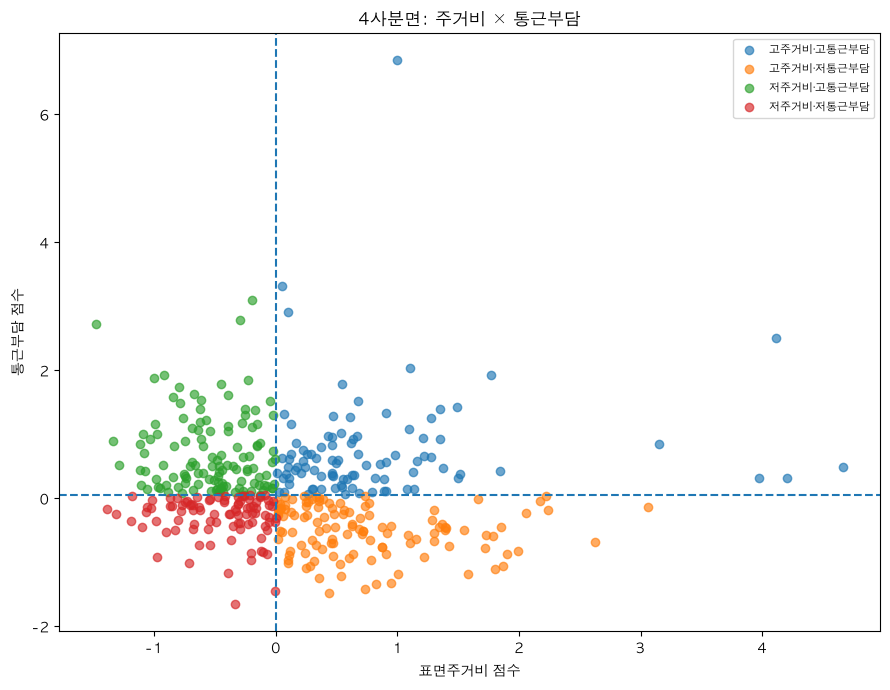

In [27]:
# =========================================================
# 27. 4사분면 유형화
# =========================================================

quadrant = analysis_data.copy()

burden_z = pd.DataFrame(
    RobustScaler().fit_transform(
        quadrant[BURDEN_FEATURES]
    ),
    columns=BURDEN_FEATURES,
    index=quadrant.index,
)

structure_z = pd.DataFrame(
    RobustScaler().fit_transform(
        quadrant[STRUCTURE_FEATURES]
    ),
    columns=STRUCTURE_FEATURES,
    index=quadrant.index,
)

quadrant["주거비점수"] = burden_z["표면주거비_원"]
quadrant["통근부담점수"] = burden_z[
    ["대표_편도통근시간_분", "월통근교통비_원"]
].mean(axis=1)
quadrant["종합부담점수"] = burden_z.mean(axis=1)
quadrant["지역집중통근구조점수"] = (
    structure_z["동일통근권_내부출근비율"]
    - structure_z["목적지_정규화엔트로피"]
) / 2

h_cut = quadrant["주거비점수"].median()
c_cut = quadrant["통근부담점수"].median()
b_cut = quadrant["종합부담점수"].median()
s_cut = quadrant["지역집중통근구조점수"].median()

quadrant["4사분면_주거통근"] = np.select(
    [
        (quadrant["주거비점수"] <= h_cut) & (quadrant["통근부담점수"] <= c_cut),
        (quadrant["주거비점수"] <= h_cut) & (quadrant["통근부담점수"] > c_cut),
        (quadrant["주거비점수"] > h_cut) & (quadrant["통근부담점수"] <= c_cut),
        (quadrant["주거비점수"] > h_cut) & (quadrant["통근부담점수"] > c_cut),
    ],
    [
        "저주거비·저통근부담",
        "저주거비·고통근부담",
        "고주거비·저통근부담",
        "고주거비·고통근부담",
    ],
)

quadrant["4사분면_부담구조"] = np.select(
    [
        (quadrant["종합부담점수"] <= b_cut) & (quadrant["지역집중통근구조점수"] <= s_cut),
        (quadrant["종합부담점수"] <= b_cut) & (quadrant["지역집중통근구조점수"] > s_cut),
        (quadrant["종합부담점수"] > b_cut) & (quadrant["지역집중통근구조점수"] <= s_cut),
        (quadrant["종합부담점수"] > b_cut) & (quadrant["지역집중통근구조점수"] > s_cut),
    ],
    [
        "저부담·광역분산",
        "저부담·지역집중",
        "고부담·광역분산",
        "고부담·지역집중",
    ],
)

print("[주거비 × 통근부담]")
display(quadrant["4사분면_주거통근"].value_counts().to_frame("행정동수"))

print("[종합부담 × 통근구조]")
display(quadrant["4사분면_부담구조"].value_counts().to_frame("행정동수"))

fig, ax = plt.subplots(figsize=(9, 7))
for name, g in quadrant.groupby("4사분면_주거통근"):
    ax.scatter(g["주거비점수"], g["통근부담점수"], alpha=0.65, label=name)
ax.axvline(h_cut, linestyle="--")
ax.axhline(c_cut, linestyle="--")
ax.set_xlabel("표면주거비 점수")
ax.set_ylabel("통근부담 점수")
ax.set_title("4사분면: 주거비 × 통근부담")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 28. 2단계 계층형 유형화

평면에서 한 번에 5개 변수를 넣는 방법과 별도로,
**통근구조 → 부담 세분화** 방식도 직접 비교한다.

1단계:
- 동일 통근권 내부출근비율
- 목적지 엔트로피

로 2개 또는 4개의 큰 갈래를 만든다.

2단계:
각 갈래 안에서
- 표면주거비
- 통근시간
- 교통비

로 다시 2~3개 하위유형을 만든다.

최종 유형 수가 **4~8개이고, 최소 하위유형 20개 이상**인 결과만 남긴다.


In [28]:
# =========================================================
# 28. 2단계 계층형 유형화
# =========================================================

structure_x = RobustScaler().fit_transform(
    analysis_data[STRUCTURE_FEATURES]
)
burden_df = analysis_data[BURDEN_FEATURES]

hierarchical_rows = []
hierarchical_results = {}

for macro_k in [2, 4]:
    for macro_method in ["Ward", "KMeans"]:
        if macro_method == "Ward":
            macro_labels = AgglomerativeClustering(
                n_clusters=macro_k,
                linkage="ward",
            ).fit_predict(structure_x)
        else:
            macro_labels = KMeans(
                n_clusters=macro_k,
                n_init=50,
                random_state=RANDOM_STATE,
            ).fit_predict(structure_x)

        for local_method in ["Ward", "KMeans", "GMM"]:
            final_labels = np.full(len(analysis_data), -1, dtype=int)
            next_id = 0
            success = True

            for macro_id in sorted(np.unique(macro_labels)):
                idx = np.where(macro_labels == macro_id)[0]

                if len(idx) < 40:
                    success = False
                    break

                local_x = RobustScaler().fit_transform(
                    burden_df.iloc[idx]
                )

                choices = []
                for local_k in [2, 3]:
                    if len(idx) < local_k * 20:
                        continue

                    try:
                        if local_method == "Ward":
                            labels = AgglomerativeClustering(
                                n_clusters=local_k,
                                linkage="ward",
                            ).fit_predict(local_x)
                        elif local_method == "KMeans":
                            labels = KMeans(
                                n_clusters=local_k,
                                n_init=50,
                                random_state=RANDOM_STATE,
                            ).fit_predict(local_x)
                        else:
                            labels = GaussianMixture(
                                n_components=local_k,
                                covariance_type="full",
                                n_init=20,
                                random_state=RANDOM_STATE,
                            ).fit_predict(local_x)

                        counts = pd.Series(labels).value_counts()
                        if counts.min() < 20:
                            continue

                        choices.append((
                            silhouette_score(local_x, labels),
                            labels,
                            local_k,
                        ))
                    except Exception:
                        pass

                if not choices:
                    success = False
                    break

                choices.sort(key=lambda x: x[0], reverse=True)
                labels = choices[0][1]

                for local_id in sorted(np.unique(labels)):
                    mask = labels == local_id
                    final_labels[idx[mask]] = next_id
                    next_id += 1

            if not success or (final_labels < 0).any():
                continue

            n_final = len(np.unique(final_labels))
            if not 4 <= n_final <= 8:
                continue

            counts = pd.Series(final_labels).value_counts()
            max_ratio = counts.max() / len(final_labels)

            eval_x = StandardScaler().fit_transform(
                analysis_data[BURDEN_FEATURES + STRUCTURE_FEATURES]
            )

            sil = silhouette_score(eval_x, final_labels)
            ch = calinski_harabasz_score(eval_x, final_labels)
            db = davies_bouldin_score(eval_x, final_labels)

            proportions = counts / counts.sum()
            balance_entropy = (
                -(proportions * np.log(proportions)).sum()
                / np.log(len(proportions))
            )

            tmp = pd.DataFrame(
                eval_x,
                columns=BURDEN_FEATURES + STRUCTURE_FEATURES,
            )
            tmp["cluster"] = final_labels
            centers = tmp.groupby("cluster").mean().to_numpy()
            d = pairwise_distances(centers)
            separation = d[np.triu_indices_from(d, k=1)].mean()

            key = (macro_k, macro_method, local_method, n_final)
            hierarchical_results[key] = final_labels

            hierarchical_rows.append({
                "macro_k": macro_k,
                "1단계방법": macro_method,
                "2단계방법": local_method,
                "최종군집수": n_final,
                "최소군집크기": int(counts.min()),
                "최대군집크기": int(counts.max()),
                "최대군집비율": float(max_ratio),
                "Silhouette": sil,
                "Calinski_Harabasz": ch,
                "Davies_Bouldin": db,
                "군집균형엔트로피": float(balance_entropy),
                "프로파일분리도": float(separation),
                "엄격크기적격": (
                    counts.min() >= 30
                    and max_ratio <= 0.38
                ),
            })

hierarchical_scores = pd.DataFrame(hierarchical_rows)

if len(hierarchical_scores):
    hs = hierarchical_scores.copy()
    hs["점수_Silhouette"] = minmax(hs["Silhouette"])
    hs["점수_DB"] = 1 - minmax(hs["Davies_Bouldin"])
    hs["점수_균형"] = minmax(hs["군집균형엔트로피"])
    hs["점수_프로파일"] = minmax(hs["프로파일분리도"])

    hs["계층형종합점수"] = (
        0.15 * hs["점수_Silhouette"]
        + 0.10 * hs["점수_DB"]
        + 0.35 * hs["점수_균형"]
        + 0.40 * hs["점수_프로파일"]
    )

    display(
        hs.sort_values(
            ["엄격크기적격", "계층형종합점수"],
            ascending=[False, False],
        )
    )
else:
    print("조건을 만족하는 2단계 계층형 결과가 없습니다.")


조건을 만족하는 2단계 계층형 결과가 없습니다.


## 29. 최종 군집 선택 — k=6 고정

14번 비교 결과에서 6개 군집이 군집 균형, 프로파일 분리도,
반복표본 안정성, 서비스 설명력을 종합했을 때 가장 적절하다고 판단하였다.

따라서 이번 노트북에서는 **k=6으로 고정**한다.


In [29]:
# =========================================================
# 29. 최종 군집 선택 — k=6 고정
# =========================================================

SELECTED_K = 6

if SELECTED_K not in set(best_by_k["실제군집수"].astype(int)):
    raise ValueError(
        f"k={SELECTED_K} 후보가 없습니다. "
        f"가능한 k: {sorted(best_by_k['실제군집수'].astype(int).unique())}"
    )

automatic_best = best_by_k[
    best_by_k["실제군집수"].astype(int) == SELECTED_K
].iloc[0]

SELECTED_REP = automatic_best["표현"]
SELECTED_METHOD = automatic_best["방법"]
SELECTED_FAMILY = automatic_best["후보계열"]

print("[최종 선택 모델]")
print("군집 수:", SELECTED_K)
print("표현:", SELECTED_REP)
print("방법:", SELECTED_METHOD)
display(automatic_best.to_frame("값"))

selected_x, selected_labels_zero = get_candidate_labels(
    automatic_best
)

clustered = analysis_data.copy()
clustered["군집"] = selected_labels_zero + 1

# 4사분면 결과를 상위 설명 레이어로 함께 보존
clustered["4사분면_주거통근"] = (
    quadrant["4사분면_주거통근"].values
)
clustered["4사분면_부담구조"] = (
    quadrant["4사분면_부담구조"].values
)

print("\n[최종 6개 군집 크기]")
display(
    clustered["군집"]
    .value_counts()
    .sort_index()
    .rename("행정동수")
    .to_frame()
)


[최종 선택 모델]
군집 수: 6
표현: E_블록균형50_50
방법: FuzzyCMeans_m1.5


,값
표현,E_블록균형50_50
변수조합,E_블록균형50_50
표현방식,BlockBalanced
방법,FuzzyCMeans_m1.5
요청군집수,6.0000
Silhouette,0.2229
Calinski_Harabasz,127.3318
Davies_Bouldin,1.3009
최소군집크기,32
최대군집크기,117



[최종 6개 군집 크기]


,행정동수
군집,
1,55
2,79
3,76
4,68
5,117
6,32


## 30. 최종 6개 유형명

유형명은 최종 군집의 주거비·통근시간·교통비·통근구조 프로파일을 기준으로 확정한다.

1. **고비용 통근부담형**
2. **근접통근 균형형**
3. **광역분산 통근형**
4. **주거절감·장거리통근형**
5. **저주거비·지역연계형**
6. **고주거비·직주근접형**

청년 1인세대 비율은 이 유형명을 결정하는 데 사용하지 않는다.


In [30]:
# =========================================================
# 30. 최종 6개 유형명 및 프로파일
# =========================================================

PROFILE_FEATURES = list(dict.fromkeys(
    BURDEN_FEATURES
    + STRUCTURE_FEATURES_WITH_HHI
    + PROFILE_ONLY_FEATURES
))

profile_mean = (
    clustered.groupby("군집")[PROFILE_FEATURES]
    .mean()
)

cluster_counts = (
    clustered.groupby("군집")
    .size()
    .rename("행정동수")
)

profile_z = (
    profile_mean
    - analysis_data[PROFILE_FEATURES].mean()
) / analysis_data[PROFILE_FEATURES].std(ddof=0)

FINAL_TYPE_MAP = {
    1: "고비용 통근부담형",
    2: "근접통근 균형형",
    3: "광역분산 통근형",
    4: "주거절감·장거리통근형",
    5: "저주거비·지역연계형",
    6: "고주거비·직주근접형",
}

clustered["행정동_유형"] = (
    clustered["군집"].map(FINAL_TYPE_MAP)
)

profile_output = (
    profile_mean
    .join(cluster_counts)
    .reset_index()
)

profile_output["행정동_유형"] = (
    profile_output["군집"].map(FINAL_TYPE_MAP)
)

profile_output = profile_output[
    [
        "군집",
        "행정동_유형",
        "행정동수",
        *[c for c in PROFILE_FEATURES if c in profile_output.columns],
    ]
]

print("[최종 6개 유형 프로파일]")
display(profile_output.round(3))

print("\n[서울 전체 평균 대비 Z-score]")
profile_z_display = profile_z.copy()
profile_z_display.insert(
    0,
    "행정동_유형",
    [FINAL_TYPE_MAP[int(i)] for i in profile_z_display.index]
)
display(profile_z_display.round(2))


[최종 6개 유형 프로파일]


,군집,행정동_유형,행정동수,표면주거비_원,대표_편도통근시간_분,월통근교통비_원,동일통근권_내부출근비율,목적지_정규화엔트로피,목적지_HHI,청년1인세대_비율
0,1,고비용 통근부담형,55,"767,199.7750",30.1400,"73,539.6230",0.6660,0.7550,0.0260,15.1650
1,2,근접통근 균형형,79,"719,241.8340",25.6300,"64,138.9520",0.5880,0.7450,0.0290,21.9010
2,3,광역분산 통근형,76,"637,663.2040",28.3470,"65,572.1760",0.3880,0.7950,0.0180,22.1530
3,4,주거절감·장거리통근형,68,"564,719.5560",35.3170,"67,861.4160",0.4440,0.8240,0.0140,12.2040
4,5,저주거비·지역연계형,117,"593,495.8830",31.2170,"66,426.0230",0.6520,0.7790,0.0200,17.2990
5,6,고주거비·직주근접형,32,"851,113.6430",21.2780,"67,744.3440",0.7050,0.6450,0.0770,27.3180



[서울 전체 평균 대비 Z-score]


,행정동_유형,표면주거비_원,대표_편도통근시간_분,월통근교통비_원,동일통근권_내부출근비율,목적지_정규화엔트로피,목적지_HHI,청년1인세대_비율
군집,,,,,,,,
1,고비용 통근부담형,0.7700,0.1500,1.3900,0.7600,-0.2800,0.0100,-0.2800
2,근접통근 균형형,0.4200,-0.8100,-0.6400,0.1700,-0.4900,0.1800,0.2600
3,광역분산 통근형,-0.1800,-0.2300,-0.3300,-1.3400,0.5000,-0.3700,0.2800
4,주거절감·장거리통근형,-0.7100,1.2500,0.1700,-0.9200,1.0700,-0.5500,-0.5200
5,저주거비·지역연계형,-0.5000,0.3800,-0.1400,0.6500,0.1800,-0.2600,-0.1100
6,고주거비·직주근접형,1.3800,-1.7400,0.1400,1.0500,-2.4500,2.5500,0.6900


## 31. 청년 1인세대 비율 사후 해석

청년 1인세대 비율은 **군집을 만드는 변수에는 포함하지 않았다.**

대신 최종 6개 유형이 실제로 어떤 인구구성을 보이는지 확인하기 위해
사후적으로 다음을 비교한다.

- 유형별 청년 1인세대 비율 평균·중앙값
- 서울 전체 평균 대비 차이
- 유형별 분포
- Kruskal-Wallis 검정

이 분석의 목적은
“청년비율 때문에 이 유형이 만들어졌다”는 것이 아니라,

> **이미 주거·통근 구조로 형성된 유형들 사이에서 청년 1인세대 비율에도 차이가 나타나는가**

를 확인하는 것이다.

따라서 청년비율 결과는 유형의 **보조 설명**으로만 사용한다.


[유형별 청년 1인세대 비율]


,군집,행정동_유형,행정동수,평균,중앙값,표준편차,최솟값,최댓값,서울평균,서울평균대비차이,서울평균대비비율_pct,상대수준
5,6,고주거비·직주근접형,32,27.3184,27.1550,12.6792,3.8700,55.7700,18.6791,8.6394,46.2515,높음
2,3,광역분산 통근형,76,22.1526,19.4300,13.3026,4.4600,66.2900,18.6791,3.4735,18.5959,높음
1,2,근접통근 균형형,79,21.9014,19.6400,11.5561,2.2800,64.3700,18.6791,3.2223,17.2509,높음
4,5,저주거비·지역연계형,117,17.2993,13.3800,12.9350,2.6000,66.5000,18.6791,-1.3798,-7.3867,낮음
0,1,고비용 통근부담형,55,15.1649,12.2400,11.3637,1.3300,51.7900,18.6791,-3.5142,-18.8134,낮음
3,4,주거절감·장거리통근형,68,12.2041,10.7400,8.0594,2.7000,46.3400,18.6791,-6.4750,-34.6643,낮음



[Kruskal-Wallis 검정]
H statistic: 65.8484
p-value: 0.000000
→ 유형별 청년 1인세대 비율 분포에 통계적으로 유의한 차이가 있습니다.


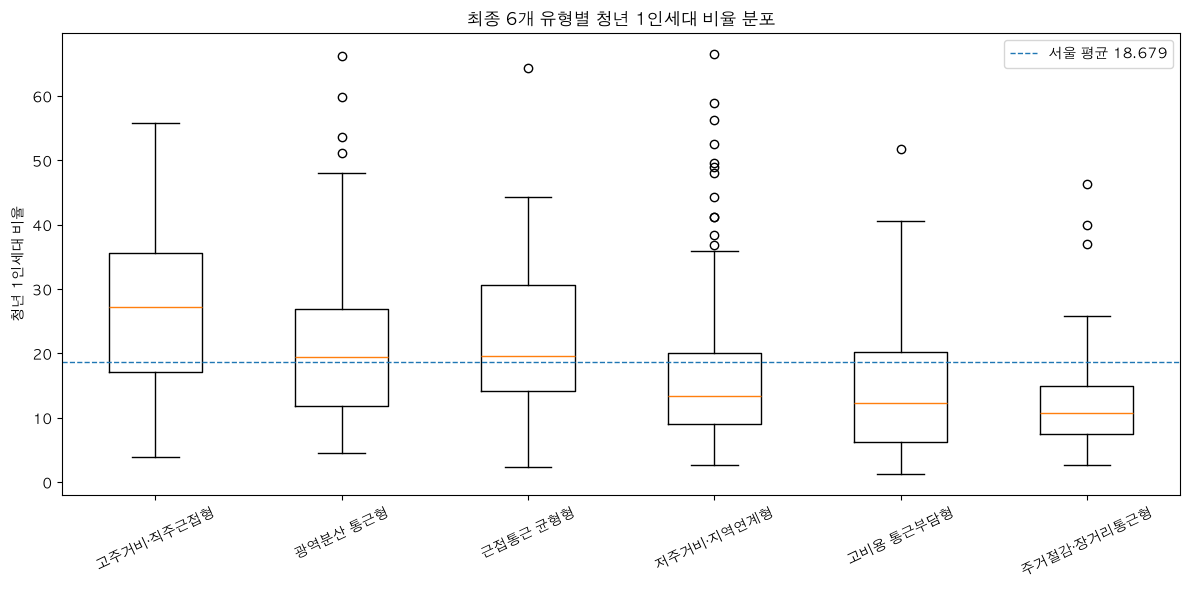


[사후 해석 문장]
- 고비용 통근부담형: 평균 15.165, 서울 평균 대비 -3.514 (낮음)
- 근접통근 균형형: 평균 21.901, 서울 평균 대비 +3.222 (높음)
- 광역분산 통근형: 평균 22.153, 서울 평균 대비 +3.474 (높음)
- 주거절감·장거리통근형: 평균 12.204, 서울 평균 대비 -6.475 (낮음)
- 저주거비·지역연계형: 평균 17.299, 서울 평균 대비 -1.380 (낮음)
- 고주거비·직주근접형: 평균 27.318, 서울 평균 대비 +8.639 (높음)


In [32]:
# =========================================================
# 31. 청년 1인세대 비율 사후 해석
# =========================================================

from scipy.stats import kruskal

YOUTH_COL = "청년1인세대_비율"

if YOUTH_COL not in clustered.columns:
    print(f"{YOUTH_COL} 컬럼이 없어 사후 해석을 건너뜁니다.")

else:
    youth_overall_mean = clustered[YOUTH_COL].mean()
    youth_overall_median = clustered[YOUTH_COL].median()

    youth_profile = (
        clustered
        .groupby(["군집", "행정동_유형"])[YOUTH_COL]
        .agg(
            행정동수="count",
            평균="mean",
            중앙값="median",
            표준편차="std",
            최솟값="min",
            최댓값="max",
        )
        .reset_index()
    )

    youth_profile["서울평균"] = youth_overall_mean
    youth_profile["서울평균대비차이"] = (
        youth_profile["평균"] - youth_overall_mean
    )

    youth_profile["서울평균대비비율_pct"] = (
        youth_profile["평균"] / youth_overall_mean - 1
    ) * 100

    youth_profile["상대수준"] = pd.cut(
        youth_profile["서울평균대비차이"],
        bins=[-np.inf, -0.02, 0.02, np.inf],
        labels=["낮음", "비슷", "높음"],
    )

    print("[유형별 청년 1인세대 비율]")
    display(
        youth_profile.sort_values(
            "평균",
            ascending=False,
        ).round(4)
    )

    # -----------------------------------------------------
    # 유형 간 차이 검정
    # -----------------------------------------------------
    groups = [
        group[YOUTH_COL].dropna().values
        for _, group in clustered.groupby("군집")
        if group[YOUTH_COL].notna().sum() > 0
    ]

    if len(groups) >= 2:
        h_stat, p_value = kruskal(*groups)

        print("\n[Kruskal-Wallis 검정]")
        print(f"H statistic: {h_stat:.4f}")
        print(f"p-value: {p_value:.6f}")

        if p_value < 0.05:
            print(
                "→ 유형별 청년 1인세대 비율 분포에 "
                "통계적으로 유의한 차이가 있습니다."
            )
        else:
            print(
                "→ 유형별 청년 1인세대 비율 차이가 "
                "통계적으로 뚜렷하다고 보기 어렵습니다."
            )

    # -----------------------------------------------------
    # 분포 시각화
    # -----------------------------------------------------
    type_order = (
        youth_profile
        .sort_values("평균", ascending=False)["행정동_유형"]
        .tolist()
    )

    fig, ax = plt.subplots(figsize=(12, 6))

    plot_data = [
        clustered.loc[
            clustered["행정동_유형"] == type_name,
            YOUTH_COL,
        ].dropna().values
        for type_name in type_order
    ]

    ax.boxplot(
        plot_data,
        tick_labels=type_order,
        showfliers=True,
    )

    ax.axhline(
        youth_overall_mean,
        linestyle="--",
        linewidth=1,
        label=f"서울 평균 {youth_overall_mean:.3f}",
    )

    ax.set_title("최종 6개 유형별 청년 1인세대 비율 분포")
    ax.set_ylabel("청년 1인세대 비율")
    ax.tick_params(axis="x", rotation=25)
    ax.legend()

    plt.tight_layout()
    plt.show()

    print("\n[사후 해석 문장]")
    for _, row in youth_profile.sort_values("군집").iterrows():
        print(
            f"- {row['행정동_유형']}: "
            f"평균 {row['평균']:.3f}, "
            f"서울 평균 대비 {row['서울평균대비차이']:+.3f} "
            f"({row['상대수준']})"
        )


## 32. 유형 대표동과 경계동

유형화의 실제 활용을 위해:
- 각 유형을 가장 잘 대표하는 행정동
- 다른 유형 사이의 경계에 가까운 행정동

을 추출한다.

경계동은 임의 확률 기준이 아니라
자기 군집 중심과 두 번째 군집 중심까지의 거리 차이가 작은 상위 15%로 정의한다.


In [33]:
# =========================================================
# 29. 대표동 / 경계동
# =========================================================

unique_clusters = sorted(
    [c for c in np.unique(selected_labels_zero) if c >= 0]
)

centers = np.vstack([
    selected_x[selected_labels_zero == c].mean(axis=0)
    for c in unique_clusters
])

dist = cdist(selected_x, centers)

nearest_order = np.argsort(dist, axis=1)
nearest_dist = np.take_along_axis(
    dist,
    nearest_order,
    axis=1,
)

clustered["자기군집중심거리"] = nearest_dist[:, 0]
clustered["두번째군집중심거리"] = nearest_dist[:, 1]
clustered["경계거리차이"] = (
    nearest_dist[:, 1] - nearest_dist[:, 0]
)

# 차이가 작을수록 경계
boundary_threshold = clustered["경계거리차이"].quantile(0.15)
clustered["군집경계_모호"] = (
    clustered["경계거리차이"] <= boundary_threshold
)

# 각 군집 내 상대적 대표성
clustered["군집내_중심거리백분위"] = (
    clustered.groupby("군집")["자기군집중심거리"]
    .rank(pct=True, ascending=True)
)

representative_dong = (
    clustered.sort_values(
        ["군집", "자기군집중심거리"]
    )
    .groupby("군집")
    .head(5)
    [
        [
            "군집",
            "행정동_유형",
            "시군구명",
            "행정동명",
            "자기군집중심거리",
            *PROFILE_FEATURES,
        ]
    ]
)

boundary_dong = (
    clustered[
        clustered["군집경계_모호"]
    ]
    .sort_values("경계거리차이")
    [
        [
            "군집",
            "행정동_유형",
            "시군구명",
            "행정동명",
            "자기군집중심거리",
            "두번째군집중심거리",
            "경계거리차이",
            *PROFILE_FEATURES,
        ]
    ]
)

print("경계동 수:", len(boundary_dong))
display(representative_dong)
display(boundary_dong.head(30))

경계동 수: 64


,군집,행정동_유형,시군구명,행정동명,자기군집중심거리,표면주거비_원,대표_편도통근시간_분,월통근교통비_원,동일통근권_내부출근비율,목적지_정규화엔트로피,목적지_HHI,청년1인세대_비율
407,1,고비용 통근부담형,송파구,잠실7동,0.3067,"714,123.5398",29.3000,"73,008.2461",0.6509,0.7800,0.0189,2.3200
244,1,고비용 통근부담형,강서구,등촌제3동,0.3121,"814,908.8050",28.8714,"74,083.7074",0.6591,0.7302,0.0286,11.2900
396,1,고비용 통근부담형,송파구,가락1동,0.3809,"832,500.0000",30.8168,"71,982.0285",0.7334,0.7702,0.0212,5.4700
352,1,고비용 통근부담형,서초구,방배1동,0.3984,"726,449.9635",26.2547,"75,148.4414",0.6924,0.7558,0.0230,17.9700
249,1,고비용 통근부담형,강서구,화곡본동,0.4011,"651,491.3517",31.8662,"74,092.0072",0.6451,0.7664,0.0187,26.6300
208,2,근접통근 균형형,마포구,공덕동,0.1306,"733,651.4132",26.7838,"63,550.7288",0.5874,0.7400,0.0273,24.0500
37,2,근접통근 균형형,용산구,원효로제2동,0.1779,"754,382.7300",26.5380,"64,087.3241",0.5646,0.7532,0.0256,19.6400
32,2,근접통근 균형형,용산구,후암동,0.1795,"713,671.7858",26.6719,"63,092.4736",0.6207,0.7427,0.0265,22.6100
0,2,근접통근 균형형,종로구,청운효자동,0.1812,"718,483.7093",26.2809,"64,666.0717",0.6325,0.7440,0.0311,13.2000
209,2,근접통근 균형형,마포구,도화동,0.2126,"749,024.4020",24.7490,"65,325.0423",0.5504,0.7443,0.0277,16.8800


,군집,행정동_유형,시군구명,행정동명,자기군집중심거리,두번째군집중심거리,경계거리차이,표면주거비_원,대표_편도통근시간_분,월통근교통비_원,동일통근권_내부출근비율,목적지_정규화엔트로피,목적지_HHI,청년1인세대_비율
264,6,고주거비·직주근접형,구로구,구로제3동,0.8990,0.8993,0.0003,"638,478.4653",25.6083,"69,872.0634",0.6009,0.6739,0.0751,37.2000
221,1,고비용 통근부담형,마포구,성산제2동,0.5567,0.5582,0.0015,"769,659.3176",30.4920,"67,677.1471",0.6243,0.7689,0.0217,27.8400
46,2,근접통근 균형형,용산구,서빙고동,0.5494,0.5513,0.0019,"610,000.0000",25.4914,"65,692.3538",0.5011,0.7722,0.0231,9.8400
315,5,저주거비·지역연계형,동작구,사당제4동,0.6575,0.6613,0.0038,"659,175.5380",25.8356,"62,235.4075",0.6680,0.7989,0.0143,27.0800
388,1,고비용 통근부담형,송파구,방이2동,0.9088,0.9169,0.0080,"848,000.9432",27.0878,"66,049.5977",0.8001,0.7409,0.0249,40.6500
250,2,근접통근 균형형,강서구,화곡제6동,0.4243,0.4346,0.0103,"652,120.8087",27.9447,"67,003.5190",0.6357,0.7516,0.0221,28.9200
104,4,주거절감·장거리통근형,중랑구,중화제2동,0.4698,0.4820,0.0122,"568,844.9848",30.1281,"66,759.3950",0.4317,0.8314,0.0120,16.4900
42,3,광역분산 통근형,용산구,이촌제2동,0.5354,0.5533,0.0179,"609,905.9140",28.7216,"64,742.0077",0.5233,0.7835,0.0245,9.5700
309,5,저주거비·지역연계형,동작구,상도제3동,0.5699,0.5879,0.0180,"601,487.2137",27.4176,"65,472.6444",0.5398,0.7967,0.0153,25.9200
29,3,광역분산 통근형,중구,동화동,0.5375,0.5566,0.0191,"687,805.9072",24.6752,"64,076.0183",0.4849,0.7833,0.0181,6.6400


## 33. PCA 시각화

최종 6개 유형의 분포를 2차원으로 축약해 시각적으로 확인한다.

PCA는 군집을 결정하는 도구가 아니라 **설명용 시각화**로만 사용한다.


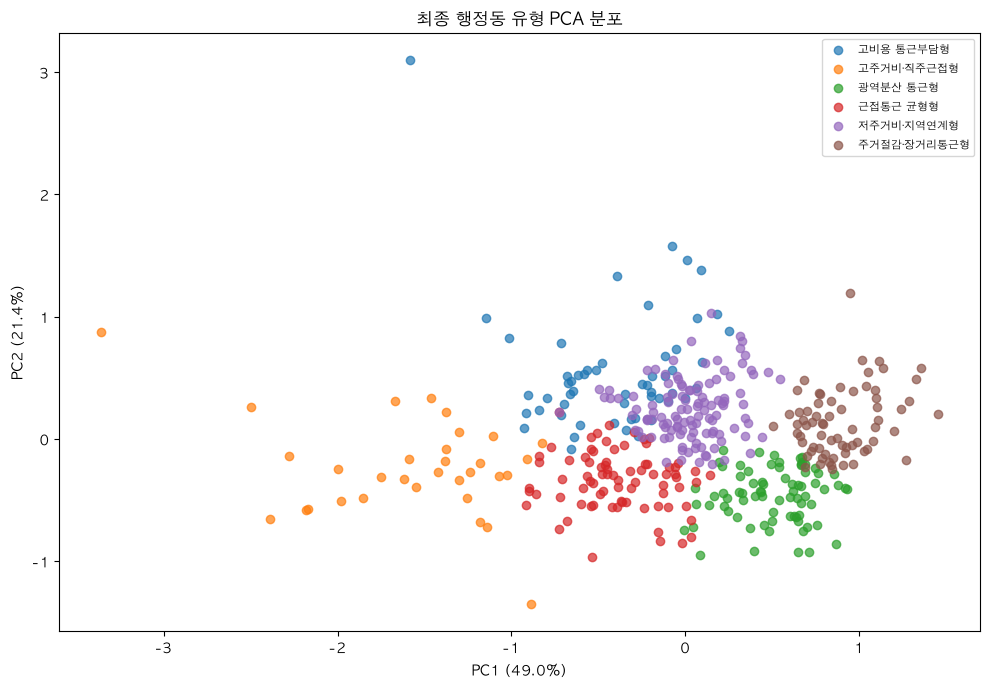

In [34]:
# =========================================================
# 30. 최종 유형 PCA 시각화
# =========================================================

pca_vis = PCA(
    n_components=2,
    random_state=RANDOM_STATE,
)
coord = pca_vis.fit_transform(selected_x)

pca_df = clustered[
    [
        "행정동코드",
        "시군구명",
        "행정동명",
        "군집",
        "행정동_유형",
    ]
].copy()

pca_df["PC1"] = coord[:, 0]
pca_df["PC2"] = coord[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))

for type_name, group in pca_df.groupby("행정동_유형"):
    ax.scatter(
        group["PC1"],
        group["PC2"],
        label=type_name,
        alpha=0.7,
    )

ax.set_xlabel(
    f"PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}%)"
)
ax.set_ylabel(
    f"PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}%)"
)
ax.set_title("최종 행정동 유형 PCA 분포")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 34. 서비스 활용 구조

### 1단계 — 4사분면
사용자가 현재 거주지의 부담구조를 빠르게 이해하는 상위 설명 레이어

### 2단계 — 6개 세부유형
현재와 다른 성격의 행정동을 탐색하는 세부 분류 레이어

### 3단계 — 실제 근무지 기준 상세비교
15번에서 실제 통근시간·교통비·시간비용·총부담을 다시 계산한다.

청년 1인세대 비율은 추천 기준이 아니라
“이 유형에는 청년 1인세대가 상대적으로 많이/적게 분포한다”는
**사후 인구 프로파일 정보**로만 활용한다.


In [35]:
# =========================================================
# 34. Final outputs
# =========================================================

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# 분석 중간/검증 결과
OUTPUT_TENDENCY = (
    PROCESSED_DIR / "dong_typology_clustering_tendency.csv"
)
OUTPUT_ALL_MODELS = (
    PROCESSED_DIR / "dong_typology_all_model_comparison.csv"
)
OUTPUT_RANKED = (
    PROCESSED_DIR / "dong_typology_ranked_candidates.csv"
)

# 최종 활용 결과
OUTPUT_PROFILE = (
    PROCESSED_DIR / "dong_typology_final_cluster_profile.csv"
)
OUTPUT_RESULT = (
    PROCESSED_DIR / "dong_typology_final.csv"
)
OUTPUT_REPRESENTATIVE = (
    PROCESSED_DIR / "dong_typology_representative_dongs.csv"
)
OUTPUT_BOUNDARY = (
    PROCESSED_DIR / "dong_typology_boundary_dongs.csv"
)
OUTPUT_HOUSING_AUDIT = (
    PROCESSED_DIR / "housing_cost_imputation_audit.csv"
)
OUTPUT_YOUTH_PROFILE = (
    PROCESSED_DIR / "dong_typology_youth_posthoc_profile.csv"
)

# ---------------------------------------------------------
# 저장
# ---------------------------------------------------------
clustering_tendency.to_csv(
    OUTPUT_TENDENCY,
    index=False,
    encoding="utf-8-sig",
)

all_candidates.to_csv(
    OUTPUT_ALL_MODELS,
    index=False,
    encoding="utf-8-sig",
)

ranked_candidates.to_csv(
    OUTPUT_RANKED,
    index=False,
    encoding="utf-8-sig",
)

profile_output.to_csv(
    OUTPUT_PROFILE,
    index=False,
    encoding="utf-8-sig",
)

representative_dong.to_csv(
    OUTPUT_REPRESENTATIVE,
    index=False,
    encoding="utf-8-sig",
)

boundary_dong.to_csv(
    OUTPUT_BOUNDARY,
    index=False,
    encoding="utf-8-sig",
)

if "housing_imputation_audit" in globals():
    housing_imputation_audit.to_csv(
        OUTPUT_HOUSING_AUDIT,
        index=False,
        encoding="utf-8-sig",
    )

if "youth_profile" in globals():
    youth_profile.to_csv(
        OUTPUT_YOUTH_PROFILE,
        index=False,
        encoding="utf-8-sig",
    )

# ---------------------------------------------------------
# 최종 행정동 유형 CSV
# ---------------------------------------------------------
RESULT_COLUMNS = [
    "행정동코드",
    "시군구명",
    "행정동명",
]

if "권역" in clustered.columns:
    RESULT_COLUMNS.append("권역")

RESULT_COLUMNS += [
    "군집",
    "행정동_유형",
    "4사분면_주거통근",
    "4사분면_부담구조",
    "자기군집중심거리",
    "두번째군집중심거리",
    "경계거리차이",
    "군집경계_모호",
    "군집내_중심거리백분위",
    *PROFILE_FEATURES,
]

for col in [
    "표면주거비_대체여부",
    "표면주거비_대체방법",
    "표면주거비_참고동",
    "청년1인세대_비율_보정여부",
    "청년1인세대_비율_보정방법",
]:
    if col in clustered.columns:
        RESULT_COLUMNS.append(col)

RESULT_COLUMNS = list(dict.fromkeys(
    [c for c in RESULT_COLUMNS if c in clustered.columns]
))

final_result = clustered[RESULT_COLUMNS].copy()

final_result.to_csv(
    OUTPUT_RESULT,
    index=False,
    encoding="utf-8-sig",
)

print("[저장 완료]")
for path in [
    OUTPUT_RESULT,
    OUTPUT_PROFILE,
    OUTPUT_REPRESENTATIVE,
    OUTPUT_BOUNDARY,
    OUTPUT_YOUTH_PROFILE,
    OUTPUT_TENDENCY,
    OUTPUT_ALL_MODELS,
    OUTPUT_RANKED,
]:
    print("-", path)


[저장 완료]
- /Users/janghwayeong/Desktop/부트캠프_프로젝트/project_data/processed/dong_typology_final.csv
- /Users/janghwayeong/Desktop/부트캠프_프로젝트/project_data/processed/dong_typology_final_cluster_profile.csv
- /Users/janghwayeong/Desktop/부트캠프_프로젝트/project_data/processed/dong_typology_representative_dongs.csv
- /Users/janghwayeong/Desktop/부트캠프_프로젝트/project_data/processed/dong_typology_boundary_dongs.csv
- /Users/janghwayeong/Desktop/부트캠프_프로젝트/project_data/processed/dong_typology_youth_posthoc_profile.csv
- /Users/janghwayeong/Desktop/부트캠프_프로젝트/project_data/processed/dong_typology_clustering_tendency.csv
- /Users/janghwayeong/Desktop/부트캠프_프로젝트/project_data/processed/dong_typology_all_model_comparison.csv
- /Users/janghwayeong/Desktop/부트캠프_프로젝트/project_data/processed/dong_typology_ranked_candidates.csv


## 최종 결론

최종 서비스용 유형화는 다음 구조를 사용한다.

**상위 설명:** 4사분면  
**세부 유형:** 6개 행정동 유형  
**인구 프로파일:** 청년 1인세대 비율 사후 해석  
**개인화 비교:** 15번 실제 근무지 기준 분석

청년 1인세대 비율은 군집 생성에 영향을 주지 않으며,
유형별 특성을 보완해서 설명하는 용도로만 사용한다.

최종 행정동 유형 파일:
`dong_typology_final.csv`
